<a href="https://colab.research.google.com/github/developerNitin/2ndFlutterApp/blob/master/NLPBois_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#COMP 6781 Project - NLP Bois

#Dataset Preparation and Exploration

Firstly I download the important libraries and also download the Hate Speech and Offensive Language Dataset from  https://www.kaggle.com/datasets/mrmorj/hate-speech-and-offensive-language-dataset/data

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
!pip install kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrmorj/hate-speech-and-offensive-language-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.01M/1.01M [00:00<00:00, 2.03MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mrmorj/hate-speech-and-offensive-language-dataset/versions/1


In [ ]:
# I get the path to the dataset and then load the csv file
dataset_path = "/root/.cache/kagglehub/datasets/mrmorj/hate-speech-and-offensive-language-dataset/versions/1"

for file in os.listdir(dataset_path):
    if file.endswith('.csv'):
        file_path = os.path.join(dataset_path, file)
        hate_speech = pd.read_csv(file_path)
        print(f"Loaded: {file}")
        break






Loaded: labeled_data.csv


I then examine the loaded dataset - hate_speech and see some rows from it

In [ ]:

print(f"Dataset shape: {hate_speech.shape}")
print(f"Number of rows: {hate_speech.shape[0]:,}")
print(f"Number of columns: {hate_speech.shape[1]}")

print("\n Column names and data types:")
print(hate_speech.dtypes)

print("\nFirst 5 rows:")
print(hate_speech.head())

print("\n Last 5 rows:")
print(hate_speech.tail())

Dataset shape: (24783, 7)
Number of rows: 24,783
Number of columns: 7

 Column names and data types:
Unnamed: 0             int64
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
class                  int64
tweet                 object
dtype: object

First 5 rows:
   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!

As we can see from above only the **class** and the **tweet** column are relevant for our project thus we remove the rest of the columns

In [ ]:
columns_to_keep = ['tweet', 'class']
hate_speech = hate_speech[columns_to_keep]
print(hate_speech.head())

                                               tweet  class
0  !!! RT @mayasolovely: As a woman you shouldn't...      2
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...      1
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...      1
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...      1
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...      1


I then check for missing values just in case

In [ ]:
print(hate_speech.isnull().sum())

print(f"\nTotal missing values: {hate_speech.isnull().sum().sum()}")
print(f"Dataset shape: {hate_speech.shape}")

tweet    0
class    0
dtype: int64

Total missing values: 0
Dataset shape: (24783, 2)


Fortunately no missing values are there so next I explore the tweet column since it's the most important for us in terms of cleaning and preprocessing and see what characters and symbols to remove along with checking the class distribution in the dataset

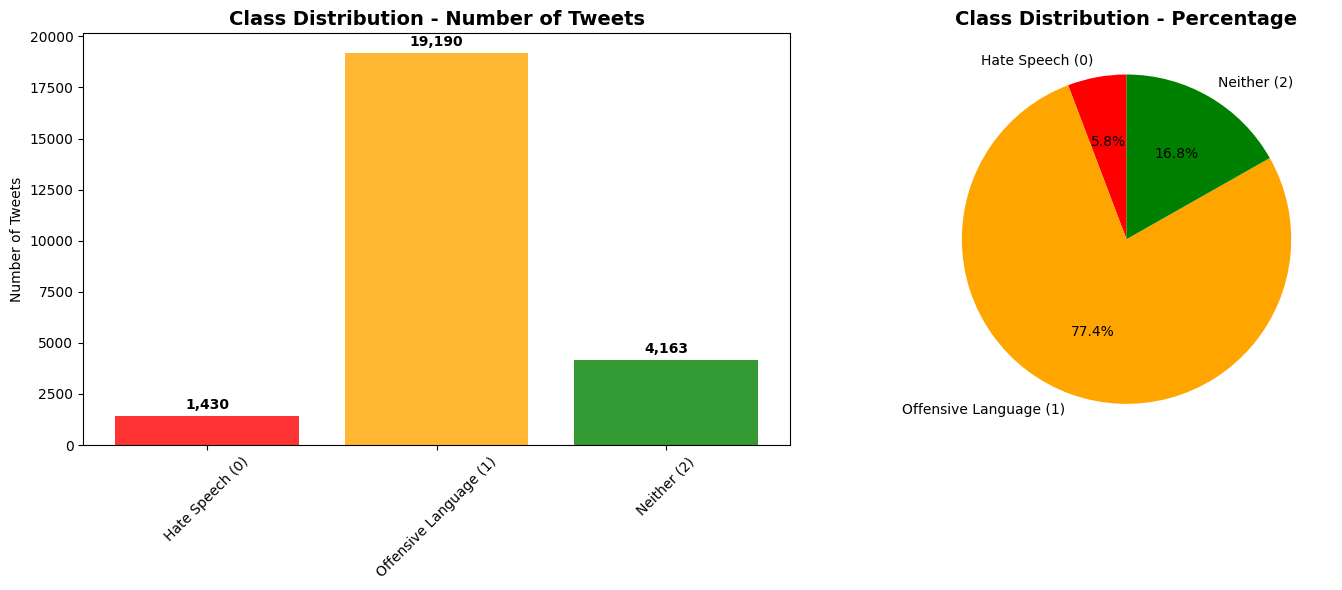

In [ ]:


plt.style.use('default')
sns.set_palette("husl")


class_counts = hate_speech['class'].value_counts().sort_index()
class_percentages = (hate_speech['class'].value_counts(normalize=True).sort_index() * 100).round(2)


class_data = {
    'Class': ['Hate Speech (0)', 'Offensive Language (1)', 'Neither (2)'],
    'Count': [class_counts[0], class_counts[1], class_counts[2]],
    'Percentage': [class_percentages[0], class_percentages[1], class_percentages[2]]
}

df_class = pd.DataFrame(class_data)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


axes[0].bar(df_class['Class'], df_class['Count'], color=['red', 'orange', 'green'], alpha=0.8)
axes[0].set_title('Class Distribution - Number of Tweets', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')
axes[0].tick_params(axis='x', rotation=45)

for i, count in enumerate(df_class['Count']):
    axes[0].text(i, count + max(df_class['Count'])*0.01, f'{count:,}', ha='center', va='bottom', fontweight='bold')


colors = ['red', 'orange', 'green']
axes[1].pie(df_class['Count'], labels=df_class['Class'], autopct='%1.1f%%',
           colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


As we can observe from above that the dataset is highly imbalanced with the Offensive Language Class being 77% of the entire dataset , meaning that the model can simply just guess Offensive Language all the time and still be correct majority of the cases , thus looking at the more than sufficient overrrepresented Offensive Language Class I believe undersampling it would be appropriate

BEFORE BALANCING:
Hate Speech (0): 1,430
Offensive Language (1): 19,190
Neither (2): 4,163

AFTER BALANCING:
Class 0: 1,430 tweets
Class 1: 6,244 tweets
Class 2: 4,163 tweets


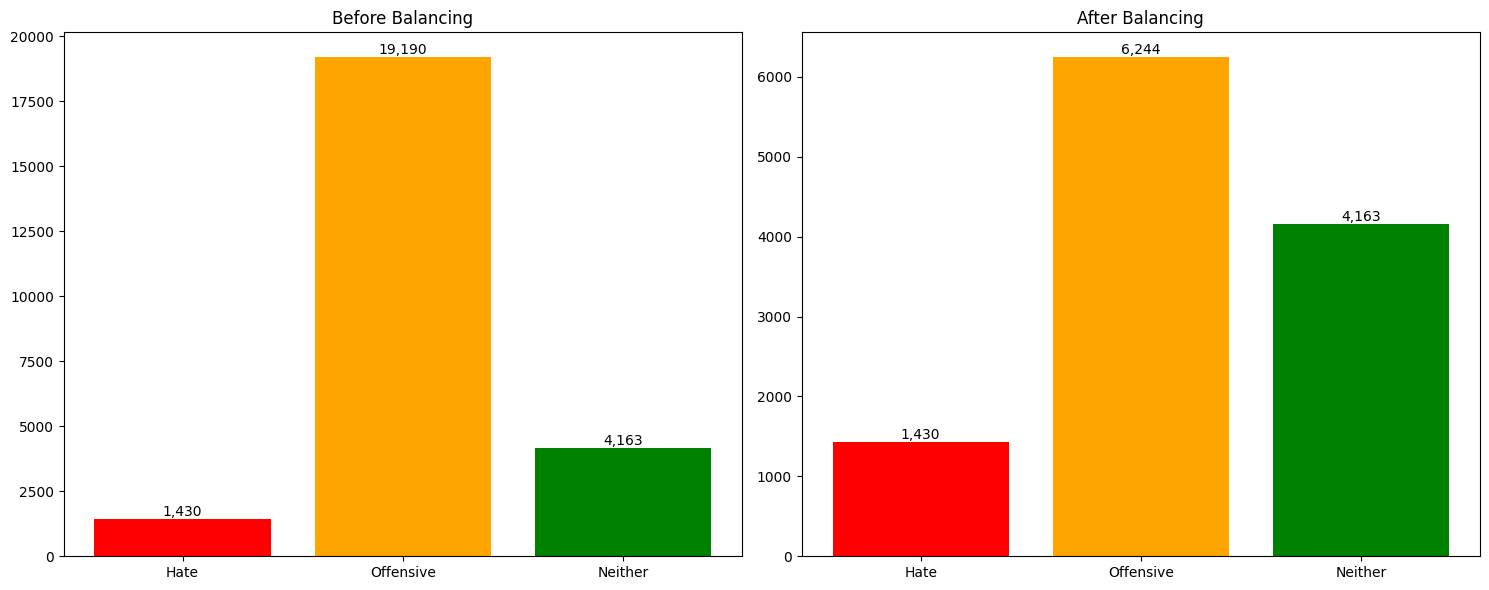

In [ ]:
from sklearn.utils import resample

df_hate = hate_speech[hate_speech['class'] == 0]
df_offensive = hate_speech[hate_speech['class'] == 1]
df_neither = hate_speech[hate_speech['class'] == 2]

print("BEFORE BALANCING:")
print(f"Hate Speech (0): {len(df_hate):,}")
print(f"Offensive Language (1): {len(df_offensive):,}")
print(f"Neither (2): {len(df_neither):,}")

target_size = int(len(df_neither) * 1.5)

df_offensive_balanced = resample(df_offensive,
                                replace=False,
                                n_samples=target_size,
                                random_state=42)

df_balanced = pd.concat([df_hate, df_offensive_balanced, df_neither])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nAFTER BALANCING:")
balanced_counts = df_balanced['class'].value_counts().sort_index()
for class_val, count in balanced_counts.items():
    print(f"Class {class_val}: {count:,} tweets")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

original_counts = hate_speech['class'].value_counts().sort_index()
axes[0].bar(['Hate', 'Offensive', 'Neither'], original_counts.values, color=['red', 'orange', 'green'])
axes[0].set_title('Before Balancing')
for i, count in enumerate(original_counts):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom')

axes[1].bar(['Hate', 'Offensive', 'Neither'], balanced_counts.values, color=['red', 'orange', 'green'])
axes[1].set_title('After Balancing')
for i, count in enumerate(balanced_counts):
    axes[1].text(i, count, f'{count:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

hate_speech_balanced = df_balanced

Now the dataset is more balanced than before and we also made sure we didn't loose too much of the Offensive Language class samples after undersampling , but still later weights will be necessary and accuracy will be misleading due to the still slight overabundance of the Offensive Language class

Now I check what characters and symbols are there in the tweets to remove

In [ ]:
import re
from collections import Counter


def analyze_tweet_content(text_series, sample_size=8000):
    sample_texts = text_series.sample(min(sample_size, len(text_series)), random_state=42)
    all_text = ' '.join(sample_texts.astype(str))


    urls = re.findall(r'https?://\S+|www\.\S+', all_text)
    mentions = re.findall(r'@\w+', all_text)
    hashtags = re.findall(r'#\w+', all_text)
    symbols = re.findall(r'[^\w\s@#]', all_text)
    emojis = re.findall(r'[^\x00-\x7F]+', all_text)
    rt_patterns = re.findall(r'\bRT\b', all_text, re.IGNORECASE)

    print("CONTENT ANALYSIS:")
    print(f"URLs: {len(set(urls))} unique")
    print(f"Mentions: {len(set(mentions))} unique")
    print(f"Hashtags: {len(set(hashtags))} unique")
    print(f"Special symbols: {len(set(symbols))} unique")
    print(f"Emojis: {len(set(emojis))} unique")
    print(f"RT patterns: {len(rt_patterns)} total")

    return len(set(urls)), len(set(mentions)), len(set(hashtags))


urls_count, mentions_count, hashtags_count = analyze_tweet_content(hate_speech_balanced['tweet'])



CONTENT ANALYSIS:
URLs: 1157 unique
Mentions: 5075 unique
Hashtags: 1420 unique
Special symbols: 26 unique
Emojis: 0 unique
RT patterns: 2420 total


As we can see from the above analysis , there are plenty of URLs,mentions and #s to remove from the dataset, as we don't them to be part of the vocabulary nor to play a part in the models thus basically I only want to keep the English characters and turn all the tweets to lowercase to standardise them

In [ ]:
def clean_tweet_for_mnb(tweet):
    if not isinstance(tweet, str):
        return ""

    tweet = tweet.lower()

    # Remove URLs
    tweet = re.sub(r'https?://\S+|www\.\S+', '', tweet)

    # Remove mentions
    tweet = re.sub(r'@\w+', '', tweet)

    # Remove hashtags but keep the text
    tweet = re.sub(r'#(\w+)', r'\1', tweet)

    # Remove RT indicators
    tweet = re.sub(r'\brt\b', '', tweet)

    # Keep only English alphabets (lowercase) spaces
    tweet = re.sub(r'[^a-z\s]', '', tweet)

    # Remove extra whitespace
    tweet = re.sub(r'\s+', ' ', tweet)
    return tweet.strip()

# Apply cleaning
hate_speech_char_rem = hate_speech_balanced.copy()
hate_speech_char_rem['cleaned_tweet'] = hate_speech_char_rem['tweet'].apply(clean_tweet_for_mnb)

# Compare samples
print("BEFORE vs AFTER CLEANING:")
for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"BEFORE: {hate_speech_char_rem['tweet'].iloc[i]}")
    print(f"AFTER:  {hate_speech_char_rem['cleaned_tweet'].iloc[i]}")


BEFORE vs AFTER CLEANING:

Sample 1:
BEFORE: @EntMagazine @magisto @digitalskeptic we have a project that could lead into a military program but requires a full op mock up for testing
AFTER:  we have a project that could lead into a military program but requires a full op mock up for testing

Sample 2:
BEFORE: My best friend loves Justin beiber what a fag &#128557;&#128514;&#128557; @Cryystalina
AFTER:  my best friend loves justin beiber what a fag

Sample 3:
BEFORE: RT @Brittanny188: Pull up on my ex make that bitch mad&#128514;&#128514;&#128128;&#128128;
AFTER:  pull up on my ex make that bitch mad


Now I again only keep the cleaned_tweet and the class columns from the **hate_speech_char_rem dataset**

In [ ]:
hate_speech_char_rem = hate_speech_char_rem[['cleaned_tweet', 'class']]
print(hate_speech_char_rem.head())

                                       cleaned_tweet  class
0  we have a project that could lead into a milit...      2
1      my best friend loves justin beiber what a fag      0
2               pull up on my ex make that bitch mad      1
3  ive met few people in politics that i disrespe...      2
4  this guys company had best year everunder obam...      2


Now I want to filter out closed class words/stop words as they carry little meaning like prepositions and determiners etc.. also knowing that I removed all punctuations I am accounting for stopwords like **ive** and **hes** also seperately

In [ ]:
import nltk
from nltk.corpus import stopwords


nltk.download('stopwords')

def remove_stopwords(text):
    if not isinstance(text, str):
        return ""


    stop_words = set(stopwords.words('english'))

    # Additional words to remove (contractions without punctuation)
    additional_stopwords = {
        'im', 'ive', 'id', 'ill', 'hes', 'hed','shes', 'shed', 'shell',
        'were', 'wed', 'well', 'theyre', 'theyd', 'theyll', 'thats', 'thatll',
        'whos', 'whod', 'wholl', 'whats', 'whatre', 'whens', 'wheres', 'whys',
        'hows', 'cant', 'dont', 'wont', 'shouldnt', 'couldnt', 'wouldnt',
        'isnt', 'arent', 'wasnt', 'werent', 'hasnt', 'havent', 'hadnt'
    }

    stop_words.update(additional_stopwords)


    words = text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 1]

    return ' '.join(filtered_words)

hate_speech_stop = hate_speech_char_rem.copy()
hate_speech_stop['cleaned_tweet'] = hate_speech_stop['cleaned_tweet'].apply(remove_stopwords)

# Compare samples before and after stop word removal
print("BEFORE vs AFTER STOP WORD REMOVAL:")
for i in range(3):
    print(f"\nSample {i+1}:")

    before_stopwords = hate_speech_char_rem['cleaned_tweet'].iloc[i]
    after_stopwords = hate_speech_stop['cleaned_tweet'].iloc[i]

    print(f"BEFORE STOPWORDS: {before_stopwords}")
    print(f"AFTER STOPWORDS:  {after_stopwords}")


print(f"\nFinal dataset shape: {hate_speech_stop.shape}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


BEFORE vs AFTER STOP WORD REMOVAL:

Sample 1:
BEFORE STOPWORDS: we have a project that could lead into a military program but requires a full op mock up for testing
AFTER STOPWORDS:  project could lead military program requires full op mock testing

Sample 2:
BEFORE STOPWORDS: my best friend loves justin beiber what a fag
AFTER STOPWORDS:  best friend loves justin beiber fag

Sample 3:
BEFORE STOPWORDS: pull up on my ex make that bitch mad
AFTER STOPWORDS:  pull ex make bitch mad

Final dataset shape: (11837, 2)


Now after preprocessing and cleaning the dataset, I split it into 80-10-10 for training,validation and testing respectively

In [ ]:
from sklearn.model_selection import train_test_split

hate_speech_train, temp_data = train_test_split(hate_speech_stop, test_size=0.2, random_state=42, stratify=hate_speech_stop['class'])
hate_speech_val, hate_speech_test = train_test_split(temp_data, test_size=0.5, random_state=42, stratify=temp_data['class'])

print("DATASET SPLIT (80-10-10):")
print(f"Training set: {len(hate_speech_train):,} samples ({len(hate_speech_train)/len(hate_speech_stop)*100:.1f}%)")
print(f"Validation set: {len(hate_speech_val):,} samples ({len(hate_speech_val)/len(hate_speech_stop)*100:.1f}%)")
print(f"Test set: {len(hate_speech_test):,} samples ({len(hate_speech_test)/len(hate_speech_stop)*100:.1f}%)")

DATASET SPLIT (80-10-10):
Training set: 9,469 samples (80.0%)
Validation set: 1,184 samples (10.0%)
Test set: 1,184 samples (10.0%)


# Model 1 - Multinomial Naive Bayes Classifier

Now I'm ready for my model 1 : **Multinomial Naive Bayes Classifier With TF-IDF**

Firstly , I will import all the necessary packages

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score
import numpy as np

Then I Initialize TF-IDF Vectorizer following Bag-of-Words model

In [ ]:
# We represent each document as a vector of <word, value> pairs using tf.idf weighting scheme
tfidf_vectorizer = TfidfVectorizer(
   min_df=3,           # Hapax legomena rule filter: where some words only appear once, thus we remove word types that appear in fewer than 3 documents
                      #Prevents overfitting to noise in the training data and also ensures Multinomial Naive Bayes has sufficient data for probability estimation
    max_df=0.95          # Remove only extremely common words (like appearing in >95% of tweets)
                     # As these overly common words lack discriminative power for classification
)



So the above following Zipfs laws rule ensures that the words are in just the right amount to be meaningful : not excessively much and not exceedingly rare

Now I convert text documents to numerical feature vectors using TF-IDF weighting

In [ ]:
# Convert text documents to numerical feature vectors using TF-IDF weighting
train_tfidf = tfidf_vectorizer.fit_transform(hate_speech_train['cleaned_tweet'])
val_tfidf = tfidf_vectorizer.transform(hate_speech_val['cleaned_tweet'])
test_tfidf = tfidf_vectorizer.transform(hate_speech_test['cleaned_tweet'])

print(f"Training features shape: {train_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")  # Total number of word types in our Vocabulary


Training features shape: (9469, 3541)
Vocabulary size: 3,541


As we can see from the output above (shape of the training features) there are 9469 tweets and 3541 word features

Now we define the target variables basically the hypothesis classes H_i: P(Class | Text)

In [ ]:
y_train = hate_speech_train['class']    # Training labels: 0=hate_speech, 1=offensive, 2=neither
y_val = hate_speech_val['class']        # Validation labels for hyperparameter tuning
y_test = hate_speech_test['class']      # Test labels for final evaluation



In [ ]:
print(f"Class distribution - Hate Speech (0): {(y_train == 0).sum()}, "
      f"Offensive (1): {(y_train == 1).sum()}, Neither (2): {(y_train == 2).sum()}")



Class distribution - Hate Speech (0): 1144, Offensive (1): 4995, Neither (2): 3330


As we can observe from the above output the class distribution is decently well balanced since when we initially downloaded it and examined it

Now our Feature and Target Preparation is complete! Finally we can train our **Multinomial Naive Bayes Classifier**!!!

In [ ]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB(alpha=1.0)  # We do Laplace smoothing where δ=1 to to handle the zero-frequency problem
mnb.fit(train_tfidf, y_train) # This implements C_NB = argmax[P(C_i) × Π P(word_j|C_i)]

MultinomialNB()

In [ ]:
print(f"Learned class priors: {mnb.classes_}")

Learned class priors: [0 1 2]


The model training is completed!

Next we do **hyperparameter tuning** using the **validation set** to find the best smoothing value for our model

In [ ]:
# Firstly importing the required metrics for evaluation
from sklearn.metrics import precision_recall_fscore_support, fbeta_score, accuracy_score
import numpy as np

In [ ]:
# Various alpha values
alpha_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
print(f"\nTesting smoothing parameters (α): {alpha_values}")
print("α = δ in Laplace formula: P(w_j|C_i) = (freq + δ) / (tokens + δ×|V|)")


Testing smoothing parameters (α): [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
α = δ in Laplace formula: P(w_j|C_i) = (freq + δ) / (tokens + δ×|V|)


In [ ]:
best_alpha = None
best_f2_hate_speech = 0
best_recall_hate_speech = 0
best_model = None

In [ ]:
print("\nHyperparameter Tuning Results:")
print("α" + " " * 4 + "| F2-Score | Recall   | Precision | Hate Preds | Correct")
print("-" * 65)

for alpha in alpha_values:
    # Training on training set to learn the values of the parameters of the model like prior probabilities and likelihood probabilities
    mnb_temp = MultinomialNB(alpha=alpha)
    mnb_temp.fit(train_tfidf, y_train)

    #Evaluating on VALIDATION set
    y_val_pred = mnb_temp.predict(val_tfidf)

    # Calculate metrics on validation set
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average=None)
    f2_hate_speech = fbeta_score(y_val, y_val_pred, beta=2, average=None)[0]

    # Count predictions and correct classifications for hate speech
    hate_predictions = (y_val_pred == 0).sum()
    correct_hate = ((y_val_pred == 0) & (y_val == 0)).sum()
    actual_hate = (y_val == 0).sum()

    print(f"α={alpha:4.1f} | {f2_hate_speech:8.4f} | {recall[0]:7.4f} | {precision[0]:9.4f} | {hate_predictions:10} | {correct_hate:7}")

    # Select best model based on F2-score for hate speech like we described in our project proposal as undetected hate speech content is going to cause more problems than wrongly predicting neutral(neither class) content as hate speech
    if f2_hate_speech > best_f2_hate_speech:
        best_f2_hate_speech = f2_hate_speech
        best_recall_hate_speech = recall[0]
        best_alpha = alpha
        best_model = mnb_temp


Hyperparameter Tuning Results:
α    | F2-Score | Recall   | Precision | Hate Preds | Correct
-----------------------------------------------------------------
α= 0.1 |   0.2707 |  0.2378 |    0.6071 |         56 |      34
α= 0.5 |   0.2224 |  0.1888 |    0.7714 |         35 |      27
α= 1.0 |   0.1431 |  0.1189 |    0.7727 |         22 |      17
α= 2.0 |   0.0261 |  0.0210 |    1.0000 |          3 |       3
α= 5.0 |   0.0000 |  0.0000 |    0.0000 |          0 |       0
α=10.0 |   0.0000 |  0.0000 |    0.0000 |          0 |       0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


As we can observe from above the best alpha value is 0.1

In [ ]:
print(f"   Optimal α (smoothing): {best_alpha}")
print(f"   F2-Score (Hate Speech): {best_f2_hate_speech:.4f}")
print(f"   Recall (Hate Speech): {best_recall_hate_speech:.4f} ({best_recall_hate_speech*100:.1f}%)")
print(f"   Improvement: {best_recall_hate_speech*100:.1f}% vs initial 11.9% detection rate")

   Optimal α (smoothing): 0.1
   F2-Score (Hate Speech): 0.2707
   Recall (Hate Speech): 0.2378 (23.8%)
   Improvement: 23.8% vs initial 11.9% detection rate


Now we train the final model with the best smoothing value of 0.1

In [ ]:
final_mnb = MultinomialNB(alpha=0.1)  # Use the best α we found
final_mnb.fit(train_tfidf, y_train)   # Train on original training set

print("Final model training complete!")
print(f"   Optimal α = 0.1 (Laplace smoothing)")
print(f"   Training data: {train_tfidf.shape[0]:,} samples")

Final model training complete!
   Optimal α = 0.1 (Laplace smoothing)
   Training data: 9,469 samples


Now we do our evaluation on our **Test Set** using our trained model on the best smoothing value

In [ ]:
y_test_pred = final_mnb.predict(test_tfidf)
y_test_proba = final_mnb.predict_proba(test_tfidf)

# Overall accuracy
accuracy = accuracy_score(y_test, y_test_pred)
print(f"\n1. OVERALL ACCURACY: {accuracy:.4f}")

print("\n2. HATE SPEECH FOCUSED METRICS (Class 0):")
print("-" * 50)

# Calculate detailed metrics for each class
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_test_pred, average=None)
f2_scores = fbeta_score(y_test, y_test_pred, beta=2, average=None)

class_names = ['Hate Speech (0)', 'Offensive (1)', 'Neither (2)']
for i, name in enumerate(class_names):
    print(f"   {name:15} → Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, "
          f"F1: {f1[i]:.4f}, F2: {f2_scores[i]:.4f}")


print(f"\n3. KEY PROJECT METRIC - Hate Speech Recall:")
print(f"    We detect {recall[0]*100:.1f}% of actual hate speech posts")
print(f"    Improvement: {recall[0]*100:.1f}% vs initial 11.9%")



1. OVERALL ACCURACY: 0.7863

2. HATE SPEECH FOCUSED METRICS (Class 0):
--------------------------------------------------
   Hate Speech (0) → Precision: 0.6207, Recall: 0.2517, F1: 0.3582, F2: 0.2857
   Offensive (1)   → Precision: 0.7606, Recall: 0.9200, F1: 0.8327, F2: 0.8830
   Neither (2)     → Precision: 0.8649, Recall: 0.7692, F1: 0.8142, F2: 0.7866

3. KEY PROJECT METRIC - Hate Speech Recall:
    We detect 25.2% of actual hate speech posts
    Improvement: 25.2% vs initial 11.9%


Now we plot the Confusion Matrix for our Test set to see an easy to understand overview of its predictions vs the ground truths


CONFUSION MATRIX - MULTINOMIAL NAIVE BAYES


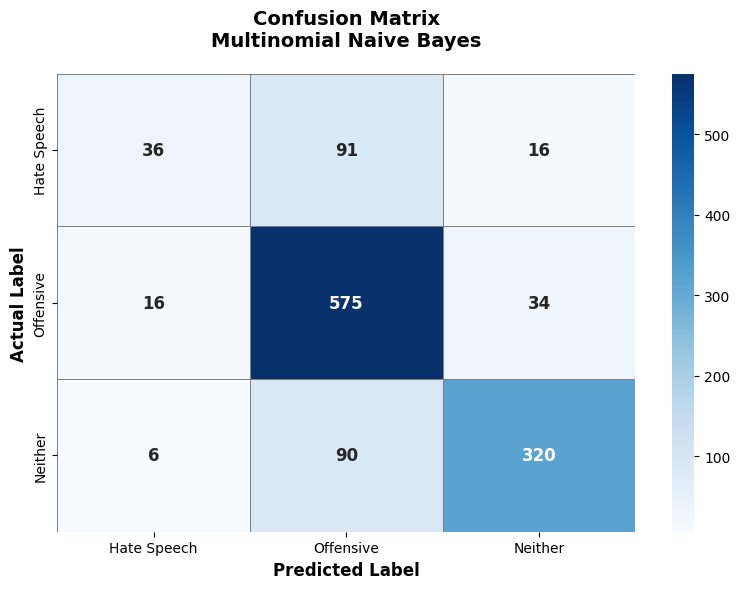


HATE SPEECH DETECTION PERFORMANCE
  - Actual hate speech posts: 143
  - Correctly detected: 36
  - Missed (false negatives): 107
  - Detection rate: 25.2%


In [ ]:
from sklearn.metrics import confusion_matrix

# **Confusion Matrix Visualization**
print("\n" + "="*70)
print("CONFUSION MATRIX - MULTINOMIAL NAIVE BAYES")
print("="*70)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create confusion matrix plot
plt.figure(figsize=(8, 6))

# Create heatmap
class_names = ['Hate Speech', 'Offensive', 'Neither']
ax = sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                cbar=True,
                xticklabels=class_names,
                yticklabels=class_names,
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.5,
                linecolor='gray')

# Customize the plot
plt.title('Confusion Matrix\nMultinomial Naive Bayes',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Hate Speech Detection Details
print("\n" + "="*70)
print("HATE SPEECH DETECTION PERFORMANCE")
print("="*70)

# Calculate metrics specifically for Hate Speech (Class 0)
actual_hate = cm[0, :].sum() # Sum of all actual hate speech samples
true_positives = cm[0, 0]    # Correctly predicted hate speech
false_negatives = cm[0, 1] + cm[0, 2] # Actual hate speech predicted as offensive or neither

print(f"  - Actual hate speech posts: {actual_hate}")
print(f"  - Correctly detected: {true_positives}")
print(f"  - Missed (false negatives): {false_negatives}")
print(f"  - Detection rate: {true_positives/actual_hate*100:.1f}%")


Here is class by class report of our models performance on the test set

In [ ]:

print("\n DETAILED CLASSIFICATION REPORT:")
print("-" * 40)
print(classification_report(y_test, y_test_pred,
                          target_names=['Hate Speech (0)', 'Offensive (1)', 'Neither (2)']))


 DETAILED CLASSIFICATION REPORT:
----------------------------------------
                 precision    recall  f1-score   support

Hate Speech (0)       0.62      0.25      0.36       143
  Offensive (1)       0.76      0.92      0.83       625
    Neither (2)       0.86      0.77      0.81       416

       accuracy                           0.79      1184
      macro avg       0.75      0.65      0.67      1184
   weighted avg       0.78      0.79      0.77      1184



Lastly I do my own tests using the vocabulary available to draft our own tweet/sentence to check the models performance for that sample

In [ ]:
# **Explore Vocabulary and Create Test Sentences**
print("\n" + "="*70)
print("VOCABULARY EXPLORATION - Words the Model Learned")
print("="*70)

# Get the vocabulary from the TF-IDF vectorizer
vocabulary = tfidf_vectorizer.get_feature_names_out()
print(f"Total vocabulary size: {len(vocabulary):,} words")

# Display sample of words from the vocabulary
print(f"\nSample of words in vocabulary (first 2000):")
print([vocabulary[i] for i in range(min(2000, len(vocabulary)))])


VOCABULARY EXPLORATION - Words the Model Learned
Total vocabulary size: 3,541 words

Sample of words in vocabulary (first 2000):
['aa', 'aap', 'ability', 'able', 'abo', 'abortion', 'absolute', 'absolutely', 'absurd', 'abt', 'abu', 'abuse', 'abusive', 'accent', 'accept', 'acceptable', 'accident', 'accidentally', 'according', 'account', 'accounts', 'accurate', 'accused', 'across', 'act', 'actin', 'acting', 'action', 'activities', 'actor', 'acts', 'actual', 'actually', 'ad', 'adam', 'add', 'addicted', 'address', 'admit', 'adorable', 'ads', 'adult', 'adults', 'advanced', 'advice', 'ae', 'af', 'afc', 'afford', 'afraid', 'african', 'afterwards', 'age', 'ago', 'agree', 'agreed', 'ah', 'ahead', 'aid', 'aids', 'ainn', 'aint', 'air', 'aka', 'al', 'alabama', 'albino', 'album', 'alcohol', 'alex', 'algebra', 'alike', 'alive', 'allah', 'allowed', 'allstar', 'almost', 'alone', 'along', 'alot', 'already', 'alright', 'als', 'also', 'always', 'amazing', 'amber', 'amendment', 'america', 'american', 'ame

Now using the above sample words I create sentences to check the models performance first hand

In [ ]:
# **Test Sentences for Hate Speech Detection**
print("\n" + "="*70)
print("TESTING HATE SPEECH DETECTION")
print("="*70)

# Test sentences covering different types of content
test_sentences = [
    # Clear hate speech
    "That chink should go back to china",
    "All spics are lazy and stupid",
    "Those wetbacks don't belong here",
    "Kikes control all the money",
    "Coon behavior is always ghetto",
    "I hate all muslims they are terrorists",
    "Black people are genetically inferior",
    "Women belong in the kitchen not in offices",
    "All immigrants should be deported immediately",
    "White power is the only way forward",

    # Offensive but not necessarily hate speech
    "You're such a stupid idiot with no brain",
    "This is fucking ridiculous you moron",
    "What a pathetic loser you are",

    # Neutral content
    "The weather is nice today and I love summer",
    "I enjoyed reading that book it was interesting",
    "Can you please help me with this problem"
]

print("Testing sentence classification:\n")

for i, sentence in enumerate(test_sentences):
    sentence_tfidf = tfidf_vectorizer.transform([sentence])
    prediction = final_mnb.predict(sentence_tfidf)[0]
    probabilities = final_mnb.predict_proba(sentence_tfidf)[0]

    print(f"Test {i+1:2d}: '{sentence}'")
    print(f"  → Prediction: {class_names[prediction]} (Confidence: {probabilities[prediction]:.3f})")
    print(f"  Probabilities: Hate: {probabilities[0]:.3f}, Offensive: {probabilities[1]:.3f}, Neither: {probabilities[2]:.3f}")
    print()


TESTING HATE SPEECH DETECTION
Testing sentence classification:

Test  1: 'That chink should go back to china'
  → Prediction: Offensive (Confidence: 0.486)
  Probabilities: Hate: 0.395, Offensive: 0.486, Neither: 0.118

Test  2: 'All spics are lazy and stupid'
  → Prediction: Offensive (Confidence: 0.792)
  Probabilities: Hate: 0.055, Offensive: 0.792, Neither: 0.152

Test  3: 'Those wetbacks don't belong here'
  → Prediction: Hate Speech (Confidence: 0.767)
  Probabilities: Hate: 0.767, Offensive: 0.193, Neither: 0.040

Test  4: 'Kikes control all the money'
  → Prediction: Offensive (Confidence: 0.869)
  Probabilities: Hate: 0.012, Offensive: 0.869, Neither: 0.119

Test  5: 'Coon behavior is always ghetto'
  → Prediction: Neither (Confidence: 0.478)
  Probabilities: Hate: 0.269, Offensive: 0.253, Neither: 0.478

Test  6: 'I hate all muslims they are terrorists'
  → Prediction: Neither (Confidence: 0.552)
  Probabilities: Hate: 0.356, Offensive: 0.093, Neither: 0.552

Test  7: 'Black

Since the dataset even after undersampling was still unbalanced we use weighted metrics to account for this and see our models actual performance given the datasets unequal distribution

So firstly , we analyse the exact distribution of the dataset

In [ ]:
# 1. First, analyze the original class distribution
print("1. ORIGINAL DATASET CLASS DISTRIBUTION:")
print("-" * 40)

original_distribution = {
    'Hate Speech': 1430,
    'Offensive': 6244,
    'Neither': 4163
}

total_original = sum(original_distribution.values())
print(f"Total samples in original dataset: {total_original:,}")

print("\nClass Distribution:")
print("Class           |   Count | Percentage | Weight")
print("-" * 50)
for class_name, count in original_distribution.items():
    percentage = (count / total_original) * 100
    weight = count / total_original
    print(f"{class_name:15} | {count:>7,} | {percentage:>9.1f}% | {weight:>.3f}")

# 2. Analyze test set distribution
print(f"\n2. TEST SET CLASS DISTRIBUTION:")
print("-" * 40)

test_distribution = {
    'Hate Speech': (y_test == 0).sum(),
    'Offensive': (y_test == 1).sum(),
    'Neither': (y_test == 2).sum()
}

total_test = sum(test_distribution.values())
print(f"Total samples in test set: {total_test:,}")

print("\nTest Set Distribution:")
print("Class           |   Count | Percentage")
print("-" * 40)
for class_name, count in test_distribution.items():
    percentage = (count / total_test) * 100
    print(f"{class_name:15} | {count:>7} | {percentage:>9.1f}%")

1. ORIGINAL DATASET CLASS DISTRIBUTION:
----------------------------------------
Total samples in original dataset: 11,837

Class Distribution:
Class           |   Count | Percentage | Weight
--------------------------------------------------
Hate Speech     |   1,430 |      12.1% | 0.121
Offensive       |   6,244 |      52.7% | 0.527
Neither         |   4,163 |      35.2% | 0.352

2. TEST SET CLASS DISTRIBUTION:
----------------------------------------
Total samples in test set: 1,184

Test Set Distribution:
Class           |   Count | Percentage
----------------------------------------
Hate Speech     |     143 |      12.1%
Offensive       |     625 |      52.8%
Neither         |     416 |      35.1%


Then after finding out the exact distribution , we calculate the corresponding weighted metrics

In [ ]:
# Weighted Metrics Calculation across all classes
print(f"\nWEIGHTED METRICS (Accounts for class imbalance)")
print("-" * 50)

from sklearn.metrics import precision_recall_fscore_support, fbeta_score

# Calculate weighted metrics
weighted_precision = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')[0]
weighted_recall = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')[1]
weighted_f1 = precision_recall_fscore_support(y_test, y_test_pred, average='weighted')[2]
weighted_f2 = fbeta_score(y_test, y_test_pred, beta=2, average='weighted')

print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1-score:  {weighted_f1:.4f}")
print(f"Weighted F2-score:  {weighted_f2:.4f}")


WEIGHTED METRICS (Accounts for class imbalance)
--------------------------------------------------
Weighted Precision: 0.7803
Weighted Recall:    0.7863
Weighted F1-score:  0.7689
Weighted F2-score:  0.7770


Now we compare these weighted metrics with the macro which treat all classes equally

In [ ]:
# **Detailed Side-by-Side Comparison**
print(f"\nDETAILED SIDE-BY-SIDE COMPARISON")
print("=" * 70)

# Get macro averages for comparison (treats all classes equally)
macro_precision = precision_recall_fscore_support(y_test, y_test_pred, average='macro')[0]
macro_recall = precision_recall_fscore_support(y_test, y_test_pred, average='macro')[1]
macro_f1 = precision_recall_fscore_support(y_test, y_test_pred, average='macro')[2]
macro_f2 = fbeta_score(y_test, y_test_pred, beta=2, average='macro')

print("Metric           | Weighted   | Macro      | Difference")
print("-" * 55)
print(f"Precision       | {weighted_precision:10.4f} | {macro_precision:10.4f} | {weighted_precision - macro_precision:10.4f}")
print(f"Recall          | {weighted_recall:10.4f} | {macro_recall:10.4f} | {weighted_recall - macro_recall:10.4f}")
print(f"F1-score        | {weighted_f1:10.4f} | {macro_f1:10.4f} | {weighted_f1 - macro_f1:10.4f}")
print(f"F2-score        | {weighted_f2:10.4f} | {macro_f2:10.4f} | {weighted_f2 - macro_f2:10.4f}")




DETAILED SIDE-BY-SIDE COMPARISON
Metric           | Weighted   | Macro      | Difference
-------------------------------------------------------
Precision       |     0.7803 |     0.7487 |     0.0316
Recall          |     0.7863 |     0.6470 |     0.1393
F1-score        |     0.7689 |     0.6684 |     0.1005
F2-score        |     0.7770 |     0.6518 |     0.1252


#Model 2 - FFNN

Now we move onto our **model 2: Feed Forward Neural Network with embeddings**

Initially we planned to use GoogleNews-vectors-negative300 embeddings for it's huge Vocabulary of about 3 million words/phrases and it's news domain relevance but later we discovered it was trained on older news of 2013 while our dataset is consisting of tweets around 2020 creating a significant mismatch between the old news training data and modern tweets, which could hurt hate speech detection performance.



Thus we chose to use FastText Embeddings(**fasttext-wiki-news-subwords-300**) for this project as they handle out-of-vocabulary words via subword information which is perfect for misspellings common in hate speech as we also saw earlier in our samples when we were exploring our initial dataset

In [ ]:
#We install the necessary libraries for the embeddings
!pip install gensim fasttext scikit-learn tensorflow --quiet


In [ ]:
# Then we import all the necessary libraries needed for FFNN creation
import gensim.downloader as api
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!!!!!")

All libraries imported successfully!!!!!


In [ ]:
# Finally we load the fasttext embeddings
print("\n" + "="*70)
print("LOADING FASTTEXT EMBEDDINGS")
print("="*70)

try:
    print("Downloading FastText embeddings...")
    ft_embeddings = api.load('fasttext-wiki-news-subwords-300')

    print("FastText embeddings loaded successfully!")
    print(f"   Vocabulary size: {len(ft_embeddings.key_to_index):,} words")
    print(f"   Embedding dimensions: {ft_embeddings.vector_size}")

except Exception as e:
    print(f"YOU GOT THE ERROR: {e}")


LOADING FASTTEXT EMBEDDINGS
FastText embeddings loaded successfully!
   Vocabulary size: 999,999 words
   Embedding dimensions: 300


Now that the embeddings are loaded , we use them to convert our 'cleaned tweets' from the preprocessed dataset earlier in train to their respective embeddings

In [ ]:
# Now we convert our preprocessed dataset from earlier to their respective embeddings
print("\n" + "="*70)
print("CONVERTING DATASET TO EMBEDDINGS")
print("="*70)

def text_to_fasttext_embedding(text, embedding_model):
    """Convert text to embedding by averaging word vectors"""
    if isinstance(text, float) or text is None:
        text = ""

    words = str(text).lower().split()
    word_vectors = []

    for word in words:
        try:
            vector = embedding_model[word]
            word_vectors.append(vector)
        except KeyError:
            continue

    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0)
    else:
        return np.zeros(embedding_model.vector_size)

# Convert all splits to embeddings
print("Converting training set...")
X_train_embeddings = np.array([text_to_fasttext_embedding(tweet, ft_embeddings)
                              for tweet in hate_speech_train['cleaned_tweet']])

print("Converting validation set...")
X_val_embeddings = np.array([text_to_fasttext_embedding(tweet, ft_embeddings)
                            for tweet in hate_speech_val['cleaned_tweet']])

print("Converting test set...")
X_test_embeddings = np.array([text_to_fasttext_embedding(tweet, ft_embeddings)
                             for tweet in hate_speech_test['cleaned_tweet']])

# Prepare target variables
y_train = hate_speech_train['class'].values
y_val = hate_speech_val['class'].values
y_test = hate_speech_test['class'].values

print(f"Embedding conversion of tweets is complete!")
print(f"   Training: {X_train_embeddings.shape}")
print(f"   Validation: {X_val_embeddings.shape}")
print(f"   Test: {X_test_embeddings.shape}")


CONVERTING DATASET TO EMBEDDINGS
Converting training set...
Converting validation set...
Converting test set...
Embedding conversion of tweets is complete!
   Training: (9469, 300)
   Validation: (1184, 300)
   Test: (1184, 300)


Now that the tweets have been converted to their respective embeddings , we can start with building our Feed Forward Neural Network!

In [ ]:
# Firslty we convert our numpy arrays to tensors
print("\n" + "="*70)
print("Converting Numpy Arrays to Tensors")
print("="*70)


print("Converting data to PyTorch tensors...")
X_train_tensor = torch.FloatTensor(X_train_embeddings)
X_val_tensor = torch.FloatTensor(X_val_embeddings)
X_test_tensor = torch.FloatTensor(X_test_embeddings)


y_train_tensor = torch.LongTensor(y_train)
y_val_tensor = torch.LongTensor(y_val)
y_test_tensor = torch.LongTensor(y_test)

print(f"Tensor shapes:")
print(f"   Training features: {X_train_tensor.shape}")
print(f"   Training labels: {y_train_tensor.shape}")


Converting Numpy Arrays to Tensors
Converting data to PyTorch tensors...
Tensor shapes:
   Training features: torch.Size([9469, 300])
   Training labels: torch.Size([9469])


Then, we create dataloaders for all 3 datasets - training, validation and testing

In [ ]:
ffnn_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
ffnn_val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
ffnn_test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64  #  setting this batch size for efficient training
ffnn_train_loader = DataLoader(ffnn_train_dataset, batch_size=batch_size, shuffle=True)
ffnn_val_loader = DataLoader(ffnn_val_dataset, batch_size=batch_size, shuffle=False)
ffnn_test_loader = DataLoader(ffnn_test_dataset, batch_size=batch_size, shuffle=False)

print(f"FFNN Data loaders created with batch size: {batch_size}")
print(f"   Training batches: {len(ffnn_train_loader)}")
print(f"   Validation batches: {len(ffnn_val_loader)}")
print(f"   Test batches: {len(ffnn_test_loader)}")

FFNN Data loaders created with batch size: 64
   Training batches: 148
   Validation batches: 19
   Test batches: 19


Now we finally build our FFNN model (it's architecture)

In [ ]:
class FFNN_HateSpeech_Simple(nn.Module):
    """
    Feed Forward Neural Network for Hate Speech,Offesnsive Language and Neither Classification
    """
    def __init__(self, input_size=300, hidden_size1=256, hidden_size2=128, num_classes=3):
        super(FFNN_HateSpeech_Simple, self).__init__()


        self.fc1 = nn.Linear(input_size, hidden_size1)  # Input to first hidden layer
        self.fc2 = nn.Linear(hidden_size1, hidden_size2) # First to second hidden layer
        self.fc3 = nn.Linear(hidden_size2, num_classes)  # Second hidden to output layer


        self.relu = nn.ReLU() # since it enables the network to learn complex patterns



    def forward(self, x):
        """
        Forward pass through the network
        Returns raw logits for CrossEntropyLoss
        """
        # Input layer to first hidden layer with ReLU activation
        x = self.relu(self.fc1(x))

        # First hidden layer to second hidden layer with ReLU activation
        x = self.relu(self.fc2(x))

        # Second hidden layer to output layer
        x = self.fc3(x)  # Raw logits for 3-class classification

        return x
#CrossEntropyLoss will handle softmax internally, hence our model's last layer doesn't need to have an activation to convert to probabilities

Now that the model architecutre is created, we need to find the best hyperparameters using the validation set ,before we train the final model with the best hyperparameters we found

In [ ]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING WITH VALIDATION SET")
print("="*70)

# Define the various hyperparameters for our model
learning_rates = [0.001, 0.0005, 0.0001]
hidden_sizes = [(256, 128), (512, 256), (128, 64)]
batch_sizes = [32, 64, 128]

best_val_accuracy = 0
best_hyperparams = {}

print("Testing hyperparameter combinations on validation set...")

for lr in learning_rates:
    for hidden_dims in hidden_sizes:
        for batch_size in batch_sizes:

            # Temporary model for this hyperparameter combination
            model_tune = FFNN_HateSpeech_Simple(
                input_size=300,
                hidden_size1=hidden_dims[0],
                hidden_size2=hidden_dims[1],
                num_classes=3
            )

            # Temporary data loaders
            train_loader_tune = DataLoader(ffnn_train_dataset, batch_size=batch_size, shuffle=True)
            val_loader_tune = DataLoader(ffnn_val_dataset, batch_size=batch_size, shuffle=False)

            # Quick training and evaluation
            optimizer_tune = optim.Adam(model_tune.parameters(), lr=lr)
            criterion_tune = nn.CrossEntropyLoss()

            # Quick training  using very few epochs to get a quick glimpse and not exhaust our collab plan before the final big training
            model_tune.train()
            for epoch in range(5):
                for data, targets in train_loader_tune:
                    outputs = model_tune(data)
                    loss = criterion_tune(outputs, targets)
                    optimizer_tune.zero_grad()
                    loss.backward()
                    optimizer_tune.step()

            # Validation evaluation
            model_tune.eval()
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for data, targets in val_loader_tune:
                    outputs = model_tune(data)
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += targets.size(0)
                    val_correct += (predicted == targets).sum().item()

            val_accuracy = 100 * val_correct / val_total

            print(f"LR: {lr}, Hidden: {hidden_dims}, Batch: {batch_size} -> Val Acc: {val_accuracy:.2f}%")

            if val_accuracy > best_val_accuracy:
                best_val_accuracy = val_accuracy
                best_hyperparams = {
                    'learning_rate': lr,
                    'hidden_size1': hidden_dims[0],
                    'hidden_size2': hidden_dims[1],
                    'batch_size': batch_size
                }
                print(f"  -> New best configuration!")

print("\n" + "="*50)
print("BEST HYPERPARAMETERS FOUND:")
print("="*50)
for param, value in best_hyperparams.items():
    print(f"  {param}: {value}")
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")


HYPERPARAMETER TUNING WITH VALIDATION SET
Testing hyperparameter combinations on validation set...
LR: 0.001, Hidden: (256, 128), Batch: 32 -> Val Acc: 84.38%
  -> New best configuration!
LR: 0.001, Hidden: (256, 128), Batch: 64 -> Val Acc: 84.88%
  -> New best configuration!
LR: 0.001, Hidden: (256, 128), Batch: 128 -> Val Acc: 83.95%
LR: 0.001, Hidden: (512, 256), Batch: 32 -> Val Acc: 84.71%
LR: 0.001, Hidden: (512, 256), Batch: 64 -> Val Acc: 85.05%
  -> New best configuration!
LR: 0.001, Hidden: (512, 256), Batch: 128 -> Val Acc: 85.47%
  -> New best configuration!
LR: 0.001, Hidden: (128, 64), Batch: 32 -> Val Acc: 84.97%
LR: 0.001, Hidden: (128, 64), Batch: 64 -> Val Acc: 84.38%
LR: 0.001, Hidden: (128, 64), Batch: 128 -> Val Acc: 84.04%
LR: 0.0005, Hidden: (256, 128), Batch: 32 -> Val Acc: 84.88%
LR: 0.0005, Hidden: (256, 128), Batch: 64 -> Val Acc: 84.12%
LR: 0.0005, Hidden: (256, 128), Batch: 128 -> Val Acc: 84.04%
LR: 0.0005, Hidden: (512, 256), Batch: 32 -> Val Acc: 84.80%

After we find the best hyperparameters from above , we create the final model with those exact hyperparameters that we will use to train for a large number of epochs

In [ ]:
print("\n" + "="*70)
print("CREATING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*70)

# Use the best hyperparameters we found
learning_rate = best_hyperparams['learning_rate']
hidden_size1 = best_hyperparams['hidden_size1']
hidden_size2 = best_hyperparams['hidden_size2']
batch_size = best_hyperparams['batch_size']

print("Creating final model with optimized hyperparameters:")
print(f"  Learning Rate: {learning_rate}")
print(f"  Hidden Layers: {hidden_size1} -> {hidden_size2}")
print(f"  Batch Size: {batch_size}")

# NOW create the final model that we'll actually train
model_final = FFNN_HateSpeech_Simple(
    input_size=300,
    hidden_size1=hidden_size1,
    hidden_size2=hidden_size2,
    num_classes=3
)

print("Final model created with optimal architecture!")


CREATING FINAL MODEL WITH BEST HYPERPARAMETERS
Creating final model with optimized hyperparameters:
  Learning Rate: 0.001
  Hidden Layers: 512 -> 256
  Batch Size: 128
Final model created with optimal architecture!


Now the most resource and time consuming part begins - The Training of the model

In [ ]:
print("\n" + "="*70)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*70)

# Create data loaders with the optimized batch size
ffnn_train_loader_final = DataLoader(ffnn_train_dataset, batch_size=batch_size, shuffle=True)
ffnn_val_loader_final = DataLoader(ffnn_val_dataset, batch_size=batch_size, shuffle=False)

# Setup training components
criterion_final = nn.CrossEntropyLoss()  # As mentioned in the proj proposal we use cross entropy loss to train and back prop
optimizer_final = optim.Adam(model_final.parameters(), lr=learning_rate)
scheduler_final = optim.lr_scheduler.StepLR(optimizer_final, step_size=10, gamma=0.1)

# Training parameters
num_epochs = 50
training_history_final = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"Starting final training for {num_epochs} epochs...")
print("Epoch | Train Loss | Val Loss | Train Acc | Val Acc | LR")

for epoch in range(num_epochs):
    # ===== TRAINING PHASE ===== (Feed-forward + Backpropagate)
    model_final.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (data, targets) in enumerate(ffnn_train_loader_final):
        # Forward pass
        outputs = model_final(data)
        loss = criterion_final(outputs, targets)

        # Backward pass and optimization
        optimizer_final.zero_grad()  # Clear previous gradients
        loss.backward()              # Backpropagation
        optimizer_final.step()       # Update weights

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += targets.size(0)
        train_correct += (predicted == targets).sum().item()

    # ===== VALIDATION PHASE =====
    model_final.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for data, targets in ffnn_val_loader_final:
            outputs = model_final(data)
            loss = criterion_final(outputs, targets)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += targets.size(0)
            val_correct += (predicted == targets).sum().item()

    # Calculate metrics
    train_loss_epoch = train_loss / len(ffnn_train_loader_final)
    val_loss_epoch = val_loss / len(ffnn_val_loader_final)
    train_acc_epoch = 100 * train_correct / train_total
    val_acc_epoch = 100 * val_correct / val_total
    current_lr = optimizer_final.param_groups[0]['lr']

    # Store history
    training_history_final['train_loss'].append(train_loss_epoch)
    training_history_final['val_loss'].append(val_loss_epoch)
    training_history_final['train_acc'].append(train_acc_epoch)
    training_history_final['val_acc'].append(val_acc_epoch)

    # Print progress
    print(f"{epoch+1:5d} | {train_loss_epoch:10.4f} | {val_loss_epoch:8.4f} | "
          f"{train_acc_epoch:8.2f}% | {val_acc_epoch:7.2f}% | {current_lr:.6f}")

    # Update learning rate
    scheduler_final.step()

print("\nFinal training completed!")


TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS
Starting final training for 50 epochs...
Epoch | Train Loss | Val Loss | Train Acc | Val Acc | LR
    1 |     0.7012 |   0.4658 |    70.98% |   82.43% | 0.001000
    2 |     0.4547 |   0.4322 |    82.94% |   82.94% | 0.001000
    3 |     0.4235 |   0.4179 |    83.85% |   84.46% | 0.001000
    4 |     0.4065 |   0.4149 |    84.68% |   84.21% | 0.001000
    5 |     0.3968 |   0.4099 |    84.93% |   84.54% | 0.001000
    6 |     0.3832 |   0.4084 |    85.63% |   84.97% | 0.001000
    7 |     0.3763 |   0.4321 |    85.70% |   83.53% | 0.001000
    8 |     0.3668 |   0.4222 |    86.31% |   84.63% | 0.001000
    9 |     0.3531 |   0.4181 |    86.59% |   85.05% | 0.001000
   10 |     0.3426 |   0.4264 |    87.27% |   84.46% | 0.001000
   11 |     0.3197 |   0.4184 |    87.76% |   85.47% | 0.000100
   12 |     0.3150 |   0.4223 |    88.06% |   85.05% | 0.000100
   13 |     0.3133 |   0.4207 |    88.26% |   85.39% | 0.000100
   14 |     0.3111 |  

Now that the training is finished, I want to save the trained model(weights) to my drive , so I can call upon it anytime

In [ ]:
print("\n" + "="*70)
print("SAVING TRAINED MODEL TO GOOGLE DRIVE")
print("="*70)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Save the trained model
model_save_path = '/content/drive/My Drive/hate_speech_ffnn_trained_model.pth'

torch.save({
    'model_state_dict': model_final.state_dict(),
    'model_architecture': model_final,
    'training_history': training_history_final,
    'best_hyperparams': best_hyperparams,
    'input_size': 300,
    'hidden_size1': hidden_size1,
    'hidden_size2': hidden_size2,
    'num_classes': 3
}, model_save_path)

print(f"Trained model saved to: {model_save_path}")
print("Model is ready for evaluation on test set!")


SAVING TRAINED MODEL TO GOOGLE DRIVE
Mounted at /content/drive
Trained model saved to: /content/drive/My Drive/hate_speech_ffnn_trained_model.pth
Model is ready for evaluation on test set!


Now that trained model is saved , we can finally test it on our test set! And evaluate it's performance

In [ ]:
#Firslty load our previously trained model from previous code block
print("\n" + "="*70)
print("LOAD TRAINED MODEL FOR EVALUATION")
print("="*70)

def load_trained_model_simple(model_path):
    print("Loading model ")

    # Load with weights_only=False since this is our own saved model
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'), weights_only=False)

    # Recreate model
    loaded_model = FFNN_HateSpeech_Simple(
        input_size=checkpoint['input_size'],
        hidden_size1=checkpoint['hidden_size1'],
        hidden_size2=checkpoint['hidden_size2'],
        num_classes=checkpoint['num_classes']
    )

    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.eval()

    print(" Model loaded successfully ")
    return loaded_model, checkpoint

# Try to load the model
try:
    model_path = '/content/drive/My Drive/hate_speech_ffnn_trained_model.pth'
    model_final, model_checkpoint = load_trained_model_simple(model_path)

    # Get the hyperparameters from the saved model
    best_hyperparams = model_checkpoint['best_hyperparams']
    training_history_final = model_checkpoint['training_history']

    print(f"Loaded model trained with:")
    print(f"   Learning Rate: {best_hyperparams['learning_rate']}")
    print(f"   Hidden Layers: {best_hyperparams['hidden_size1']} -> {best_hyperparams['hidden_size2']}")
    print(f"   Batch Size: {best_hyperparams['batch_size']}")

except Exception as e:
    print(f"Error loading model: {e}")
    print("Using the currently trained model for evaluation...")
    # Ensure current model is in evaluation mode
    model_final.eval()
    print(" Using currently trained model (in evaluation mode)")


LOAD TRAINED MODEL FOR EVALUATION
Loading model 
 Model loaded successfully 
Loaded model trained with:
   Learning Rate: 0.001
   Hidden Layers: 512 -> 256
   Batch Size: 128


Now we evaluate our **test** set similarly like we did for our MultiNomial Naive Bayes Classifier

In [ ]:
print("\n" + "="*70)
print("EVALUATING OUR FFNN MODEL ON TEST SET")
print("="*70)

batch_size = best_hyperparams['batch_size'] #Using the best batchsize we found

# Create test data loader
ffnn_test_loader = DataLoader(ffnn_test_dataset, batch_size=batch_size, shuffle=False)

# Store predictions and true labels
all_predictions = []
all_targets = []
all_probabilities = []

print("Generating predictions on test set:")
with torch.no_grad():
    for batch_idx, (data, targets) in enumerate(ffnn_test_loader):
        outputs = model_final(data)

        # Get predicted classes
        _, predicted = torch.max(outputs.data, 1)

        # Apply softmax to get probabilities
        probabilities = torch.softmax(outputs, dim=1)

        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

        # Progress update
        if (batch_idx + 1) % 10 == 0:
            print(f"  Processed {batch_idx + 1} batches...")

# Convert to numpy arrays
y_pred = np.array(all_predictions)
y_true = np.array(all_targets)
y_proba = np.array(all_probabilities)

print(f"Test set evaluation completed!")
print(f"   True labels shape: {y_true.shape}")
print(f"   Predictions shape: {y_pred.shape}")
print(f"   Probabilities shape: {y_proba.shape}")
print(f"   Samples processed: {len(y_true)}")


EVALUATING OUR FFNN MODEL ON TEST SET
Generating predictions on test set:
  Processed 10 batches...
Test set evaluation completed!
   True labels shape: (1184,)
   Predictions shape: (1184,)
   Probabilities shape: (1184, 3)
   Samples processed: 1184


In [ ]:
print("\n" + "="*70)
print("FFNN EVALUATION")
print("="*70)

# Overall accuracy
accuracy = (y_pred == y_true).mean()
print(f"\n1. OVERALL ACCURACY: {accuracy:.4f}")

print("\n2. HATE SPEECH FOCUSED METRICS (Class 0):")
print("-" * 50)

# Calculate detailed metrics for each class
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
f2_scores = fbeta_score(y_true, y_pred, beta=2, average=None)

class_names = ['Hate Speech (0)', 'Offensive (1)', 'Neither (2)']
for i, name in enumerate(class_names):
    print(f"   {name:15} → Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, "
          f"F1: {f1[i]:.4f}, F2: {f2_scores[i]:.4f}")

print(f"\n3. Hate Speech Recall:")
print(f"    We detect {recall[0]*100:.1f}% of actual hate speech posts")



FFNN EVALUATION

1. OVERALL ACCURACY: 0.8564

2. HATE SPEECH FOCUSED METRICS (Class 0):
--------------------------------------------------
   Hate Speech (0) → Precision: 0.6566, Recall: 0.4545, F1: 0.5372, F2: 0.4844
   Offensive (1)   → Precision: 0.8799, Recall: 0.9024, F1: 0.8910, F2: 0.8978
   Neither (2)     → Precision: 0.8671, Recall: 0.9255, F1: 0.8953, F2: 0.9132

3. Hate Speech Recall:
    We detect 45.5% of actual hate speech posts


Similarly we also plot the **Confusion Matrix**


CONFUSION MATRIX - FEED FORWARD NEURAL NETWORK


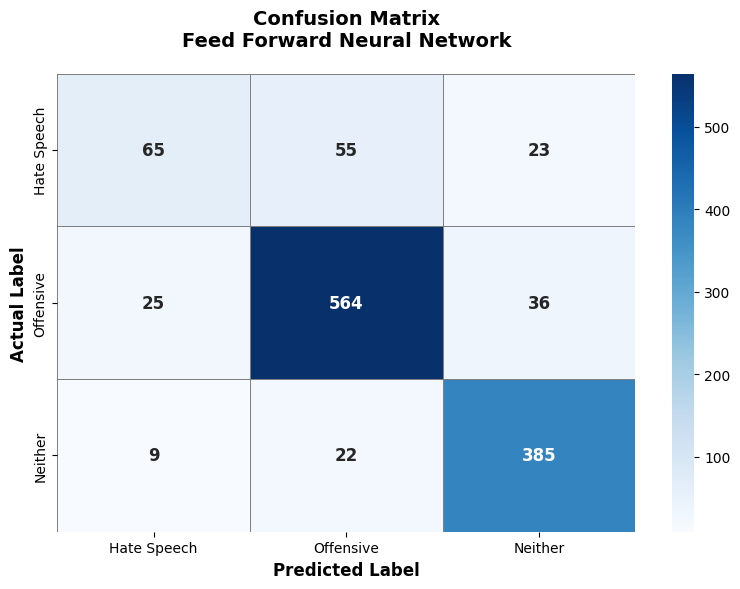


HATE SPEECH DETECTION PERFORMANCE
  - Actual hate speech posts: 143
  - Correctly detected: 65
  - Missed (false negatives): 78
  - Detection rate: 45.5%


In [ ]:
print("\n" + "="*70)
print("CONFUSION MATRIX - FEED FORWARD NEURAL NETWORK")
print("="*70)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Create confusion matrix plot
plt.figure(figsize=(8, 6))

# Create heatmap
class_names = ['Hate Speech', 'Offensive', 'Neither']
ax = sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                cbar=True,
                xticklabels=class_names,
                yticklabels=class_names,
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.5,
                linecolor='gray')

# Customize the plot
plt.title('Confusion Matrix\nFeed Forward Neural Network',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Hate Speech Detection Details
print("\n" + "="*70)
print("HATE SPEECH DETECTION PERFORMANCE")
print("="*70)

# Calculate metrics specifically for Hate Speech (Class 0)
actual_hate = cm[0, :].sum() # Sum of all actual hate speech samples
true_positives = cm[0, 0]    # Correctly predicted hate speech
false_negatives = cm[0, 1] + cm[0, 2] # Actual hate speech predicted as offensive or neither

print(f"  - Actual hate speech posts: {actual_hate}")
print(f"  - Correctly detected: {true_positives}")
print(f"  - Missed (false negatives): {false_negatives}")
print(f"  - Detection rate: {true_positives/actual_hate*100:.1f}%")

Here is the models performance class by class on our test set

In [ ]:
print("\nDETAILED CLASSIFICATION REPORT ")
print("-" * 40)
print(classification_report(y_true, y_pred,
                          target_names=['Hate Speech (0)', 'Offensive (1)', 'Neither (2)']))


DETAILED CLASSIFICATION REPORT 
----------------------------------------
                 precision    recall  f1-score   support

Hate Speech (0)       0.66      0.45      0.54       143
  Offensive (1)       0.88      0.90      0.89       625
    Neither (2)       0.87      0.93      0.90       416

       accuracy                           0.86      1184
      macro avg       0.80      0.76      0.77      1184
   weighted avg       0.85      0.86      0.85      1184



Similarly like the MultiNomial Naive Bayes Classifier's performance on sample sentences

In [ ]:
print("\n" + "="*70)
print("TESTING HATE SPEECH DETECTION WITH FFNN")
print("="*70)

# Test sentences covering different types of content
test_sentences = [
    # Clear hate speech
    "That chink should go back to china",
    "All spics are lazy and stupid",
    "Those wetbacks don't belong here",
    "Kikes control all the money",
    "Coon behavior is always ghetto",
    "I hate all muslims they are terrorists",
    "Black people are genetically inferior",
    "Women belong in the kitchen not in offices",
    "All immigrants should be deported immediately",
    "White power is the only way forward",

    # Offensive but not necessarily hate speech
    "You're such a stupid idiot with no brain",
    "This is fucking ridiculous you moron",
    "What a pathetic loser you are",

    # Neutral content
    "The weather is nice today and I love summer",
    "I enjoyed reading that book it was interesting",
    "Can you please help me with this problem"
]

print("Testing sentence classification with FFNN:\n")

for i, sentence in enumerate(test_sentences):
    # Convert sentence to FastText embedding
    sentence_embedding = text_to_fasttext_embedding(sentence, ft_embeddings)
    sentence_tensor = torch.FloatTensor(sentence_embedding).unsqueeze(0)  # Add batch dimension

    # Get prediction
    with torch.no_grad():
        outputs = model_final(sentence_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_class = torch.argmax(outputs, dim=1).item()

    class_names = ['Hate Speech', 'Offensive', 'Neither']

    print(f"Test {i+1:2d}: '{sentence}'")
    print(f"  → Prediction: {class_names[predicted_class]} (Confidence: {probabilities[predicted_class]:.3f})")
    print(f"  Probabilities: Hate: {probabilities[0]:.3f}, Offensive: {probabilities[1]:.3f}, Neither: {probabilities[2]:.3f}")
    print()


TESTING HATE SPEECH DETECTION WITH FFNN
Testing sentence classification with FFNN:

Test  1: 'That chink should go back to china'
  → Prediction: Hate Speech (Confidence: 0.644)
  Probabilities: Hate: 0.644, Offensive: 0.255, Neither: 0.101

Test  2: 'All spics are lazy and stupid'
  → Prediction: Hate Speech (Confidence: 0.646)
  Probabilities: Hate: 0.646, Offensive: 0.237, Neither: 0.116

Test  3: 'Those wetbacks don't belong here'
  → Prediction: Neither (Confidence: 0.724)
  Probabilities: Hate: 0.225, Offensive: 0.052, Neither: 0.724

Test  4: 'Kikes control all the money'
  → Prediction: Hate Speech (Confidence: 0.383)
  Probabilities: Hate: 0.383, Offensive: 0.300, Neither: 0.317

Test  5: 'Coon behavior is always ghetto'
  → Prediction: Neither (Confidence: 0.679)
  Probabilities: Hate: 0.203, Offensive: 0.118, Neither: 0.679

Test  6: 'I hate all muslims they are terrorists'
  → Prediction: Hate Speech (Confidence: 0.626)
  Probabilities: Hate: 0.626, Offensive: 0.026, Neith

Since , we already found out the class distribution in the training and test sets we can directly calculate our models performance accounting for the class imbalance using weights

In [ ]:
# Weighted Metrics Calculation across all classes
print(f"\nWEIGHTED METRICS (Accounting for class imbalance)")
print("-" * 50)

# Calculate weighted metrics
weighted_precision = precision_recall_fscore_support(y_true, y_pred, average='weighted')[0]
weighted_recall = precision_recall_fscore_support(y_true, y_pred, average='weighted')[1]
weighted_f1 = precision_recall_fscore_support(y_true, y_pred, average='weighted')[2]
weighted_f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted')

print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1-score:  {weighted_f1:.4f}")
print(f"Weighted F2-score:  {weighted_f2:.4f}")


WEIGHTED METRICS (Accounts for class imbalance)
--------------------------------------------------
Weighted Precision: 0.8484
Weighted Recall:    0.8564
Weighted F1-score:  0.8498
Weighted F2-score:  0.8533


Similarly like we did for Multinomial Naive Bayes Classifier , we do a side by side comparison of the weighted comparison where all classes are treated equally vs weighted metrics accounting for class imbalance

In [ ]:
print(f"\nDETAILED SIDE-BY-SIDE COMPARISON")
print("=" * 70)

# Get macro averages for comparison (treats all classes equally)
macro_precision = precision_recall_fscore_support(y_true, y_pred, average='macro')[0]
macro_recall = precision_recall_fscore_support(y_true, y_pred, average='macro')[1]
macro_f1 = precision_recall_fscore_support(y_true, y_pred, average='macro')[2]
macro_f2 = fbeta_score(y_true, y_pred, beta=2, average='macro')

print("Metric           | Weighted   | Macro      | Difference")
print("-" * 55)
print(f"Precision       | {weighted_precision:10.4f} | {macro_precision:10.4f} | {weighted_precision - macro_precision:10.4f}")
print(f"Recall          | {weighted_recall:10.4f} | {macro_recall:10.4f} | {weighted_recall - macro_recall:10.4f}")
print(f"F1-score        | {weighted_f1:10.4f} | {macro_f1:10.4f} | {weighted_f1 - macro_f1:10.4f}")
print(f"F2-score        | {weighted_f2:10.4f} | {macro_f2:10.4f} | {weighted_f2 - macro_f2:10.4f}")

print(f"\nFFNN MODEL ARCHITECTURE:")
print("-" * 30)
print(f"Input size: 300 (FastText embeddings)")
print(f"Hidden layers: {best_hyperparams['hidden_size1']} → {best_hyperparams['hidden_size2']}")
print(f"Output size: 3 (classes)")
print(f"Learning rate: {best_hyperparams['learning_rate']}")
print(f"Batch size: {best_hyperparams['batch_size']}")


DETAILED SIDE-BY-SIDE COMPARISON
Metric           | Weighted   | Macro      | Difference
-------------------------------------------------------
Precision       |     0.8484 |     0.8012 |     0.0472
Recall          |     0.8564 |     0.7608 |     0.0956
F1-score        |     0.8498 |     0.7745 |     0.0753
F2-score        |     0.8533 |     0.7651 |     0.0882

FFNN MODEL ARCHITECTURE:
------------------------------
Input size: 300 (FastText embeddings)
Hidden layers: 512 → 256
Output size: 3 (classes)
Learning rate: 0.001
Batch size: 128


#Model 3 - Fine Tuning RoBERTa and bert-base-uncased transformer models for our hate speech classification task

Finally, we want to fine tune the pre-trained bert-base-uncased and roberta-base transformer models on our hate speech dataset

We  begin  by  installing and importing the required libraries and again making sure we are running on the GPU

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel, AutoConfig,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Models to fine-tune
MODELS_TO_FINETUNE = [
    'bert-base-uncased',    # BERT model
    'roberta-base'          # RoBERTa model
]


Using device: cuda


Next we create the function that loads both the pretrained models for transfer learning along with loading the appropriate tokenizers

In [ ]:
def load_pretrained_models():
    """
    Load pre-trained bert-base-uncased AND roberta-base transformer models
    """
    print("=" * 70)
    print("LOADING BOTH PRE-TRAINED TRANSFORMER MODELS")
    print("=" * 70)

    models = {}
    tokenizers = {}

    for model_name in MODELS_TO_FINETUNE:
        print(f"\nLOADING {model_name.upper()}:")
        print("-" * 40)

        try:
            # Load pre-trained tokenizer
            tokenizer = AutoTokenizer.from_pretrained(model_name)

            # Load pre-trained model weights
            model = AutoModel.from_pretrained(model_name)

            # Store models and tokenizers
            tokenizers[model_name] = tokenizer
            models[model_name] = model

            print(f"✓ {model_name} loaded successfully")
            print(f"  • Hidden size: {model.config.hidden_size}")
            print(f"  • Layers: {model.config.num_hidden_layers}")
            print(f"  • Attention heads: {model.config.num_attention_heads}")

        except Exception as e:
            print(f"✗ Error loading {model_name}: {e}")

    print(f"\n SUCCESS: Loaded {len(models)} pre-trained models")
    for model_name in models.keys():
        print(f"  • {model_name}")

    return tokenizers, models

Next we create the function that adds classification heads to both pretrained models for 3-class classification into hate speech, offesnive language and neither.



In [ ]:
def add_classification_heads(models, num_classes=3):
    """
    Add classification head for 3 classes to each model
    """
    print("\n" + "=" * 70)
    print("ADDING CLASSIFICATION HEADS TO BOTH MODELS")
    print("=" * 70)

    class TransformerForHateSpeech(nn.Module):
        def __init__(self, transformer_model, num_classes):
            super(TransformerForHateSpeech, self).__init__()
            self.transformer = transformer_model
            self.dropout = nn.Dropout(0.1) # We add dropout to prevent overfitting and overelying on specific neurons and patterns and it forces the model to learn multiple ways to detect hate speech

            # ADD CLASSIFICATION HEAD FOR 3 CLASSES
            self.classifier = nn.Linear(transformer_model.config.hidden_size, num_classes)

        def forward(self, input_ids, attention_mask):
            outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)

            # Use [CLS] token for BERT, <s> token for RoBERTa
            pooled_output = outputs.last_hidden_state[:, 0, :]
            pooled_output = self.dropout(pooled_output)
            logits = self.classifier(pooled_output)

            return logits

    complete_models = {}

    for model_name, base_model in models.items():
        print(f"\n ADDING CLASSIFICATION HEAD TO {model_name.upper()}:")

        # Create complete model with classification head
        complete_model = TransformerForHateSpeech(base_model, num_classes)
        complete_model = complete_model.to(device)
        complete_models[model_name] = complete_model

        print(f" Classification head added")
        print(f"  • Input dimension: {base_model.config.hidden_size}")
        print(f"  • Output classes: {num_classes}")
        print(f"  • Total parameters: {sum(p.numel() for p in complete_model.parameters()):,}")

    return complete_models

Next we create the dataset class and data loader preparation function that handles proper tokenization and batching for both models.

In [ ]:
class HateSpeechDataset(Dataset):
    """Dataset class compatible with both BERT and RoBERTa"""
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        # Handle RoBERTa's lack of pad token
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def prepare_data_loaders_for_both_models(tokenizers, train_df, val_df, test_df):
    """
    Prepare separate data loaders for BERT and RoBERTa
    Each model has its own tokenization
    """
    print("\n" + "=" * 70)
    print("PREPARING DATA LOADERS FOR BOTH MODELS")
    print("=" * 70)


    print(f"✓ Training data columns: {list(train_df.columns)}")

    data_loaders = {}

    for model_name, tokenizer in tokenizers.items():
        print(f"\📊 PREPARING DATA FOR {model_name.upper()}:")


        train_dataset = HateSpeechDataset(train_df['cleaned_tweet'], train_df['class'], tokenizer)
        val_dataset = HateSpeechDataset(val_df['cleaned_tweet'], val_df['class'], tokenizer)
        test_dataset = HateSpeechDataset(test_df['cleaned_tweet'], test_df['class'], tokenizer)

        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

        data_loaders[model_name] = {
            'train': train_loader,
            'val': val_loader,
            'test': test_loader
        }

        print(f" Data loaders created")
        print(f"  Training batches: {len(train_loader)}")
        print(f"   Validation batches: {len(val_loader)}")
        print(f"   Test batches: {len(test_loader)}")

    return data_loaders

Next we implement the fine-tuning function that trains both models end-to-end on our hate speech dataset using the smaller learning rate for transfer learning.

In [ ]:
def fine_tune_both_models(models, data_loaders, learning_rate=2e-5, epochs=10): # 10 epochs seem good considering the compute units we have left :)
    """
    • Fine-tune both pre-trained models on our hate speech dataset
    """
    print("\n" + "=" * 70)
    print("FINE-TUNING BOTH MODELS ON HATE SPEECH DATASET")
    print("=" * 70)

    trained_models = {}
    training_histories = {}

    for model_name, model in models.items():
        print(f"\n FINE-TUNING {model_name.upper()}:")
        print("-" * 50)

        # Get data loaders for this model
        train_loader = data_loaders[model_name]['train']
        val_loader = data_loaders[model_name]['val']


        try:
            from transformers.optimization import AdamW
            optimizer = AdamW(model.parameters(), lr=learning_rate)
        except ImportError:
            from torch.optim import AdamW
            optimizer = AdamW(model.parameters(), lr=learning_rate)

        # Learning rate scheduler
        total_steps = len(train_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=total_steps
        )

        criterion = nn.CrossEntropyLoss()

        print(f" Fine-tuning configuration:")
        print(f"  • Learning rate: {learning_rate} ")
        print(f"  • Epochs: {epochs}")
        print(f"  • Training samples: {len(train_loader.dataset)}")
        print(f"  • Text column: 'cleaned_tweet'")

        # Training loop
        train_losses = []
        val_losses = []
        best_val_loss = float('inf')

        for epoch in range(epochs):
            # Training
            model.train()
            total_train_loss = 0

            train_pbar = tqdm(train_loader, desc=f'{model_name} Epoch {epoch+1}/{epochs}')
            for batch in train_pbar:
                optimizer.zero_grad()

                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

                total_train_loss += loss.item()
                train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            avg_train_loss = total_train_loss / len(train_loader)
            train_losses.append(avg_train_loss)

            # Validation
            model.eval()
            total_val_loss = 0

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['labels'].to(device)

                    logits = model(input_ids, attention_mask)
                    loss = criterion(logits, labels)
                    total_val_loss += loss.item()

            avg_val_loss = total_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)

            print(f'  Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}')

            # Save best model
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save(model.state_dict(), f'best_{model_name.replace("/", "_")}.pth')

        # Load best model
        model.load_state_dict(torch.load(f'best_{model_name.replace("/", "_")}.pth'))
        trained_models[model_name] = model
        training_histories[model_name] = {'train': train_losses, 'val': val_losses}

        print(f"✓ {model_name} fine-tuning completed")
        print(f"  • Best validation loss: {best_val_loss:.4f}")

    print(f"\n SUCCESS: Both models fine-tuned on hate speech dataset")
    print(f"   Using 'cleaned_tweet' column for text data")
    return trained_models, training_histories

Finally we create the comprehensive evaluation function that tests both fine-tuned models on the test set, providing detailed performance metrics for hate speech detection and setting up evaluation metrics similar to the previous 2 models for a fair comparison.



In [ ]:
from sklearn.metrics import precision_recall_fscore_support, fbeta_score, classification_report, confusion_matrix

def evaluate_both_models(trained_models, data_loaders):
    results = {}

    for model_name, model in trained_models.items():
        print("\n" + "="*70)
        print(f"EVALUATING {model_name.upper()} ON TEST SET")
        print("="*70)

        # Get TEST data loader
        test_loader = data_loaders[model_name]['test']

        # Store predictions and true labels
        all_predictions = []
        all_targets = []
        all_probabilities = []

        print("Generating predictions on test set:")
        model.eval()

        with torch.no_grad():
            for batch_idx, batch in enumerate(test_loader):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                targets = batch['labels'].to(device)

                # Forward pass
                outputs = model(input_ids, attention_mask)

                # Get predicted classes
                _, predicted = torch.max(outputs.data, 1)

                # Apply softmax to get probabilities
                probabilities = torch.softmax(outputs, dim=1)

                all_predictions.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())

                # Progress update
                if (batch_idx + 1) % 10 == 0:
                    print(f"  Processed {batch_idx + 1} batches...")

        # Convert to numpy arrays
        y_pred = np.array(all_predictions)
        y_true = np.array(all_targets)
        y_proba = np.array(all_probabilities)

        print(f"Test set evaluation completed!")
        print(f"   True labels shape: {y_true.shape}")
        print(f"   Predictions shape: {y_pred.shape}")
        print(f"   Probabilities shape: {y_proba.shape}")
        print(f"   Samples processed: {len(y_true)}")

        # Calculate detailed metrics
        print("\n" + "="*70)
        print(f"{model_name.upper()} EVALUATION")
        print("="*70)

        # Overall accuracy
        accuracy = (y_pred == y_true).mean()
        print(f"\n1. OVERALL ACCURACY: {accuracy:.4f}")

        print("\n2. HATE SPEECH FOCUSED METRICS (Class 0):")
        print("-" * 50)

        # Calculate detailed metrics for each class
        precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
        f2_scores = fbeta_score(y_true, y_pred, beta=2, average=None)

        class_names = ['Hate Speech (0)', 'Offensive (1)', 'Neither (2)']
        for i, name in enumerate(class_names):
            print(f"   {name:15} → Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, "
                  f"F1: {f1[i]:.4f}, F2: {f2_scores[i]:.4f}")

        print(f"\n3. Hate Speech Recall:")
        print(f"    We detect {recall[0]*100:.1f}% of actual hate speech posts")

        # Confusion Matrix
        print("\n" + "="*70)
        print(f"CONFUSION MATRIX - {model_name.upper()}")
        print("="*70)

        cm = confusion_matrix(y_true, y_pred)

        # Create confusion matrix plot
        plt.figure(figsize=(8, 6))

        # Create heatmap
        class_names_short = ['Hate Speech', 'Offensive', 'Neither']
        ax = sns.heatmap(cm,
                        annot=True,
                        fmt='d',
                        cmap='Blues',
                        cbar=True,
                        xticklabels=class_names_short,
                        yticklabels=class_names_short,
                        annot_kws={'size': 12, 'weight': 'bold'},
                        linewidths=0.5,
                        linecolor='gray')

        # Customize the plot
        plt.title(f'Confusion Matrix\n{model_name.upper()}',
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
        plt.ylabel('Actual Label', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Hate Speech Detection Details
        print("\n" + "="*70)
        print("HATE SPEECH DETECTION PERFORMANCE")
        print("="*70)

        # Calculate metrics specifically for Hate Speech (Class 0)
        actual_hate = cm[0, :].sum() # Sum of all actual hate speech samples
        true_positives = cm[0, 0]    # Correctly predicted hate speech
        false_negatives = cm[0, 1] + cm[0, 2] # Actual hate speech predicted as offensive or neither

        print(f"  - Actual hate speech posts: {actual_hate}")
        print(f"  - Correctly detected: {true_positives}")
        print(f"  - Missed (false negatives): {false_negatives}")
        print(f"  - Detection rate: {true_positives/actual_hate*100:.1f}%")

        print("\nDETAILED CLASSIFICATION REPORT ")
        print("-" * 40)
        print(classification_report(y_true, y_pred,
                                  target_names=['Hate Speech (0)', 'Offensive (1)', 'Neither (2)']))

        # Weighted Metrics Calculation across all classes
        print(f"\nWEIGHTED METRICS (Accounting for class imbalance)")
        print("-" * 50)

        # Calculate weighted metrics
        weighted_precision = precision_recall_fscore_support(y_true, y_pred, average='weighted')[0]
        weighted_recall = precision_recall_fscore_support(y_true, y_pred, average='weighted')[1]
        weighted_f1 = precision_recall_fscore_support(y_true, y_pred, average='weighted')[2]
        weighted_f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted')

        print(f"Weighted Precision: {weighted_precision:.4f}")
        print(f"Weighted Recall:    {weighted_recall:.4f}")
        print(f"Weighted F1-score:  {weighted_f1:.4f}")
        print(f"Weighted F2-score:  {weighted_f2:.4f}")

        print(f"\nDETAILED SIDE-BY-SIDE COMPARISON")
        print("=" * 70)

        # Get macro averages for comparison (treats all classes equally)
        macro_precision = precision_recall_fscore_support(y_true, y_pred, average='macro')[0]
        macro_recall = precision_recall_fscore_support(y_true, y_pred, average='macro')[1]
        macro_f1 = precision_recall_fscore_support(y_true, y_pred, average='macro')[2]
        macro_f2 = fbeta_score(y_true, y_pred, beta=2, average='macro')

        print("Metric           | Weighted   | Macro      | Difference")
        print("-" * 55)
        print(f"Precision       | {weighted_precision:10.4f} | {macro_precision:10.4f} | {weighted_precision - macro_precision:10.4f}")
        print(f"Recall          | {weighted_recall:10.4f} | {macro_recall:10.4f} | {weighted_recall - macro_recall:10.4f}")
        print(f"F1-score        | {weighted_f1:10.4f} | {macro_f1:10.4f} | {weighted_f1 - macro_f1:10.4f}")
        print(f"F2-score        | {weighted_f2:10.4f} | {macro_f2:10.4f} | {weighted_f2 - macro_f2:10.4f}")

        print(f"\n{model_name.upper()} MODEL ARCHITECTURE:")
        print("-" * 30)
        print(f"Input size: 128 tokens (max sequence length)")
        print(f"Hidden size: {model.transformer.config.hidden_size}")
        print(f"Output size: 3 (classes)")
        print(f"Learning rate: 2e-5 (fine-tuning rate)")
        print(f"Batch size: 16")

        # Store results for final comparison
        results[model_name] = {
            'accuracy': accuracy,
            'hate_speech_recall': recall[0],
            'f2_hate_speech': f2_scores[0],
            'weighted_precision': weighted_precision,
            'weighted_recall': weighted_recall,
            'weighted_f1': weighted_f1,
            'weighted_f2': weighted_f2,
            'macro_precision': macro_precision,
            'macro_recall': macro_recall,
            'macro_f1': macro_f1,
            'macro_f2': macro_f2,
            'predictions': y_pred,
            'true_labels': y_true,
            'probabilities': y_proba
        }

    return results

Similarly we also do the sample sentences classification test like before

In [ ]:
def test_sentence_classification(trained_models, tokenizers):
    print("\n" + "="*70)
    print("TESTING HATE SPEECH DETECTION WITH TRANSFORMER MODELS")
    print("="*70)

    # Test sentences we used previously
    test_sentences = [
        # Clear hate speech
        "That chink should go back to china",
        "All spics are lazy and stupid",
        "Those wetbacks don't belong here",
        "Kikes control all the money",
        "Coon behavior is always ghetto",
        "I hate all muslims they are terrorists",
        "Black people are genetically inferior",
        "Women belong in the kitchen not in offices",
        "All immigrants should be deported immediately",
        "White power is the only way forward",

        # Offensive but not necessarily hate speech
        "You're such a stupid idiot with no brain",
        "This is fucking ridiculous you moron",
        "What a pathetic loser you are",

        # Neutral content
        "The weather is nice today and I love summer",
        "I enjoyed reading that book it was interesting",
        "Can you please help me with this problem"
    ]

    for model_name, model in trained_models.items():
        print(f"\n🔍 TESTING {model_name.upper()} ON SAMPLE SENTENCES:\n")
        tokenizer = tokenizers[model_name]

        for i, sentence in enumerate(test_sentences):
            # Tokenize the sentence
            encoding = tokenizer(
                sentence,
                add_special_tokens=True,
                max_length=128,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors='pt',
            )

            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)

            # Get prediction
            model.eval()
            with torch.no_grad():
                outputs = model(input_ids, attention_mask)
                probabilities = torch.softmax(outputs, dim=1)[0]
                predicted_class = torch.argmax(outputs, dim=1).item()

            class_names = ['Hate Speech', 'Offensive', 'Neither']

            print(f"Test {i+1:2d}: '{sentence}'")
            print(f"  → Prediction: {class_names[predicted_class]} (Confidence: {probabilities[predicted_class]:.3f})")
            print(f"  Probabilities: Hate: {probabilities[0]:.3f}, Offensive: {probabilities[1]:.3f}, Neither: {probabilities[2]:.3f}")
            print()

Now we implement the main execution pipeline that begins the complete fine-tuning process and provides a final performance comparison between both transformer models.

HATE SPEECH CLASSIFICATION - BERT & ROBERTA FINE-TUNING

DATASET INFORMATION:
  Training samples: 9,469
  Validation samples: 1,184
  Test samples: 1,184
  Classes: {0: np.int64(1144), 1: np.int64(4995), 2: np.int64(3330)}
LOADING BOTH PRE-TRAINED TRANSFORMER MODELS

LOADING BERT-BASE-UNCASED:
----------------------------------------
✓ bert-base-uncased loaded successfully
  • Hidden size: 768
  • Layers: 12
  • Attention heads: 12

LOADING ROBERTA-BASE:
----------------------------------------


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ roberta-base loaded successfully
  • Hidden size: 768
  • Layers: 12
  • Attention heads: 12

 SUCCESS: Loaded 2 pre-trained models
  • bert-base-uncased
  • roberta-base

ADDING CLASSIFICATION HEADS TO BOTH MODELS

 ADDING CLASSIFICATION HEAD TO BERT-BASE-UNCASED:
 Classification head added
  • Input dimension: 768
  • Output classes: 3
  • Total parameters: 109,484,547

 ADDING CLASSIFICATION HEAD TO ROBERTA-BASE:
 Classification head added
  • Input dimension: 768
  • Output classes: 3
  • Total parameters: 124,647,939

PREPARING DATA LOADERS FOR BOTH MODELS
✓ Training data columns: ['cleaned_tweet', 'class']
\📊 PREPARING DATA FOR BERT-BASE-UNCASED:
 Data loaders created
  Training batches: 592
   Validation batches: 74
   Test batches: 74
\📊 PREPARING DATA FOR ROBERTA-BASE:
 Data loaders created
  Training batches: 592
   Validation batches: 74
   Test batches: 74

FINE-TUNING BOTH MODELS ON HATE SPEECH DATASET

 FINE-TUNING BERT-BASE-UNCASED:
------------------------------------

bert-base-uncased Epoch 1/10: 100%|██████████| 592/592 [03:27<00:00,  2.85it/s, loss=0.5727]


...

  Epoch 8: Train Loss = 0.1483, Val Loss = 0.6791


roberta-base Epoch 9/10: 100%|██████████| 592/592 [03:36<00:00,  2.74it/s, loss=0.0015]


  Epoch 9: Train Loss = 0.1158, Val Loss = 0.8059


roberta-base Epoch 10/10: 100%|██████████| 592/592 [03:36<00:00,  2.74it/s, loss=0.0027]


  Epoch 10: Train Loss = 0.0944, Val Loss = 0.8330
✓ roberta-base fine-tuning completed
  • Best validation loss: 0.3671

 SUCCESS: Both models fine-tuned on hate speech dataset
   Using 'cleaned_tweet' column for text data

EVALUATING BERT-BASE-UNCASED ON TEST SET
Generating predictions on test set:
  Processed 10 batches...
  Processed 20 batches...
  Processed 30 batches...
  Processed 40 batches...
  Processed 50 batches...
  Processed 60 batches...
  Processed 70 batches...
Test set evaluation completed!
   True labels shape: (1184,)
   Predictions shape: (1184,)
   Probabilities shape: (1184, 3)
   Samples processed: 1184

BERT-BASE-UNCASED EVALUATION

1. OVERALL ACCURACY: 0.8716

2. HATE SPEECH FOCUSED METRICS (Class 0):
--------------------------------------------------
   Hate Speech (0) → Precision: 0.6582, Recall: 0.3636, F1: 0.4685, F2: 0.3994
   Offensive (1)   → Precision: 0.8726, Recall: 0.9424, F1: 0.9062, F2: 0.9276
   Neither (2)     → Precision: 0.9093, Recall: 0.939

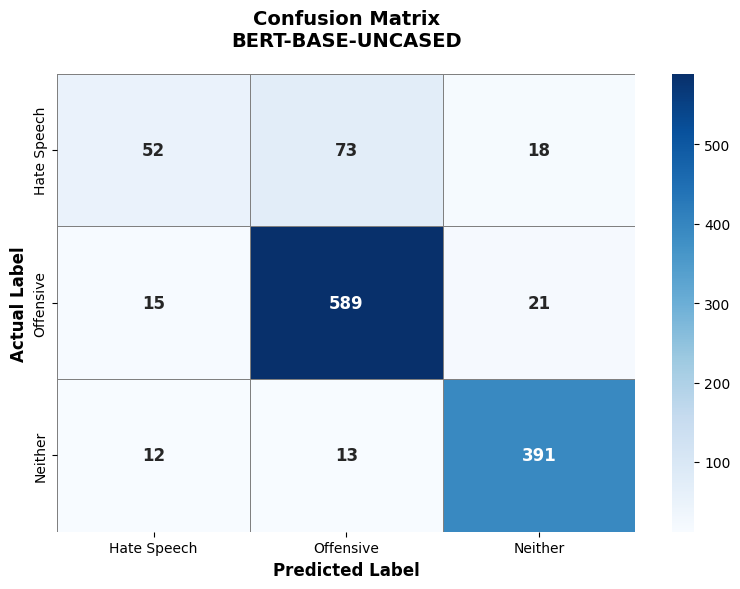


HATE SPEECH DETECTION PERFORMANCE
  - Actual hate speech posts: 143
  - Correctly detected: 52
  - Missed (false negatives): 91
  - Detection rate: 36.4%

DETAILED CLASSIFICATION REPORT 
----------------------------------------
                 precision    recall  f1-score   support

Hate Speech (0)       0.66      0.36      0.47       143
  Offensive (1)       0.87      0.94      0.91       625
    Neither (2)       0.91      0.94      0.92       416

       accuracy                           0.87      1184
      macro avg       0.81      0.75      0.77      1184
   weighted avg       0.86      0.87      0.86      1184


WEIGHTED METRICS (Accounting for class imbalance)
--------------------------------------------------
Weighted Precision: 0.8596
Weighted Recall:    0.8716
Weighted F1-score:  0.8597
Weighted F2-score:  0.8659

DETAILED SIDE-BY-SIDE COMPARISON
Metric           | Weighted   | Macro      | Difference
-------------------------------------------------------
Precision    

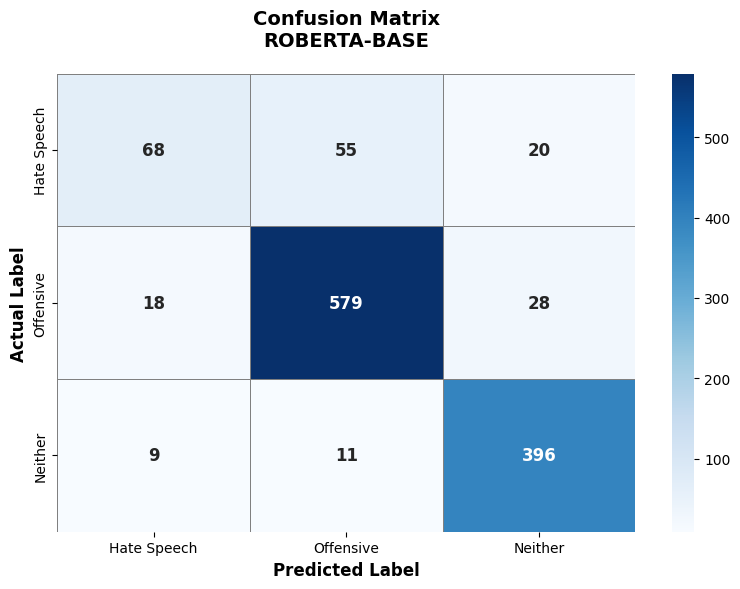


HATE SPEECH DETECTION PERFORMANCE
  - Actual hate speech posts: 143
  - Correctly detected: 68
  - Missed (false negatives): 75
  - Detection rate: 47.6%

DETAILED CLASSIFICATION REPORT 
----------------------------------------
                 precision    recall  f1-score   support

Hate Speech (0)       0.72      0.48      0.57       143
  Offensive (1)       0.90      0.93      0.91       625
    Neither (2)       0.89      0.95      0.92       416

       accuracy                           0.88      1184
      macro avg       0.84      0.78      0.80      1184
   weighted avg       0.87      0.88      0.87      1184


WEIGHTED METRICS (Accounting for class imbalance)
--------------------------------------------------
Weighted Precision: 0.8737
Weighted Recall:    0.8809
Weighted F1-score:  0.8739
Weighted F2-score:  0.8775

DETAILED SIDE-BY-SIDE COMPARISON
Metric           | Weighted   | Macro      | Difference
-------------------------------------------------------
Precision    

In [ ]:
def main():
    """
    COMPLETE PIPELINE: Fine-tune both BERT and RoBERTa on hate speech dataset
    """
    print("HATE SPEECH CLASSIFICATION - BERT & ROBERTA FINE-TUNING")
    print("=" * 70)

    # Display dataset info
    print("\nDATASET INFORMATION:")
    print(f"  Training samples: {len(hate_speech_train):,}")
    print(f"  Validation samples: {len(hate_speech_val):,}")
    print(f"  Test samples: {len(hate_speech_test):,}")
    print(f"  Classes: {dict(hate_speech_train['class'].value_counts().sort_index())}")

    # 1. Load both pre-trained models
    tokenizers, base_models = load_pretrained_models()

    # 2. Add classification heads to both models
    complete_models = add_classification_heads(base_models, num_classes=3)

    # 3. Prepare data loaders for both models
    data_loaders = prepare_data_loaders_for_both_models(tokenizers, hate_speech_train, hate_speech_val, hate_speech_test)

    # 4. Fine-tune both models on hate speech dataset
    trained_models, training_histories = fine_tune_both_models(complete_models, data_loaders, learning_rate=2e-5, epochs=10)

    # 5. Evaluate both models on TEST SET
    results = evaluate_both_models(trained_models, data_loaders)

    # 6. Test on sample sentences
    test_sentence_classification(trained_models, tokenizers)

    # 7. Final comparison
    print_final_comparison(results)

    return trained_models, results, tokenizers

def print_final_comparison(results):
    """Print final comparison between BERT and RoBERTa"""
    print("\n" + "=" * 70)
    print("FINAL COMPARISON: BERT vs RoBERTa")
    print("=" * 70)

    print("\n" + "MODEL".ljust(20) + "ACCURACY".ljust(12) + "HATE RECALL".ljust(15) + "F2-SCORE".ljust(12) + "WEIGHTED F1".ljust(12))
    print("-" * 70)

    for model_name, metrics in results.items():

        output_line = (f"{model_name.ljust(20)}"
                      f"{metrics['accuracy']:.4f}".ljust(12) +
                      f"{metrics['hate_speech_recall']:.4f}".ljust(15) +
                      f"{metrics['f2_hate_speech']:.4f}".ljust(12) +
                      f"{metrics['weighted_f1']:.4f}".ljust(12))
        print(output_line)

if __name__ == "__main__":
    # Execute complete pipeline for both models
    trained_models, results, tokenizers = main()

# Evaluation of the 3 models and Comparison between them

Now that we created, trained and evaluated the models individually , we will compare them side by side to determine which amognst them is truly the best.

Given the critical nature of detecting harmful content, our evaluation prioritizes metrics specific to the "Hate Speech" class, as its undetected presence poses the greatest societal risk. Therefore, Hate Speech Recall—the model's ability to correctly identify all actual hate speech instances—is our primary performance indicator(just like we had outlined in our project proposal). While overall accuracy provides a general snapshot of performance, it is a misleading metric here due to class imbalance(with Offensive Language class still dominating the dataset despite the undersampling)it is thus relegated to a secondary role, to be used only as a tie-breaker should models perform equally on hate-specific metrics.

In [ ]:
import pandas as pd

# Results from the previous steps
data = {
    'Model': ['MNB (TF-IDF)', 'FFNN (FastText)', 'BERT-Base', 'RoBERTa-Base'],
    'Overall Accuracy': [0.7863, 0.8564, 0.8716, 0.8809],
    'Hate Precision': [0.6207, 0.6566, 0.6582, 0.7158],
    'Hate Recall': [0.2517, 0.4545, 0.3636, 0.4755],
    'Hate F1': [0.3582, 0.5372, 0.4685, 0.5714],
    'Hate F2': [0.2857, 0.4844, 0.3994, 0.5097]
}

df = pd.DataFrame(data)
df = df.set_index('Model')

# Displaying the table
print("FINAL MODEL COMPARISON TABLE")
print(df.to_markdown())

FINAL MODEL COMPARISON TABLE
| Model           |   Overall Accuracy |   Hate Precision |   Hate Recall |   Hate F1 |   Hate F2 |
|:----------------|-------------------:|-----------------:|--------------:|----------:|----------:|
| MNB (TF-IDF)    |             0.7863 |           0.6207 |        0.2517 |    0.3582 |    0.2857 |
| FFNN (FastText) |             0.8564 |           0.6566 |        0.4545 |    0.5372 |    0.4844 |
| BERT-Base       |             0.8716 |           0.6582 |        0.3636 |    0.4685 |    0.3994 |
| RoBERTa-Base    |             0.8809 |           0.7158 |        0.4755 |    0.5714 |    0.5097 |


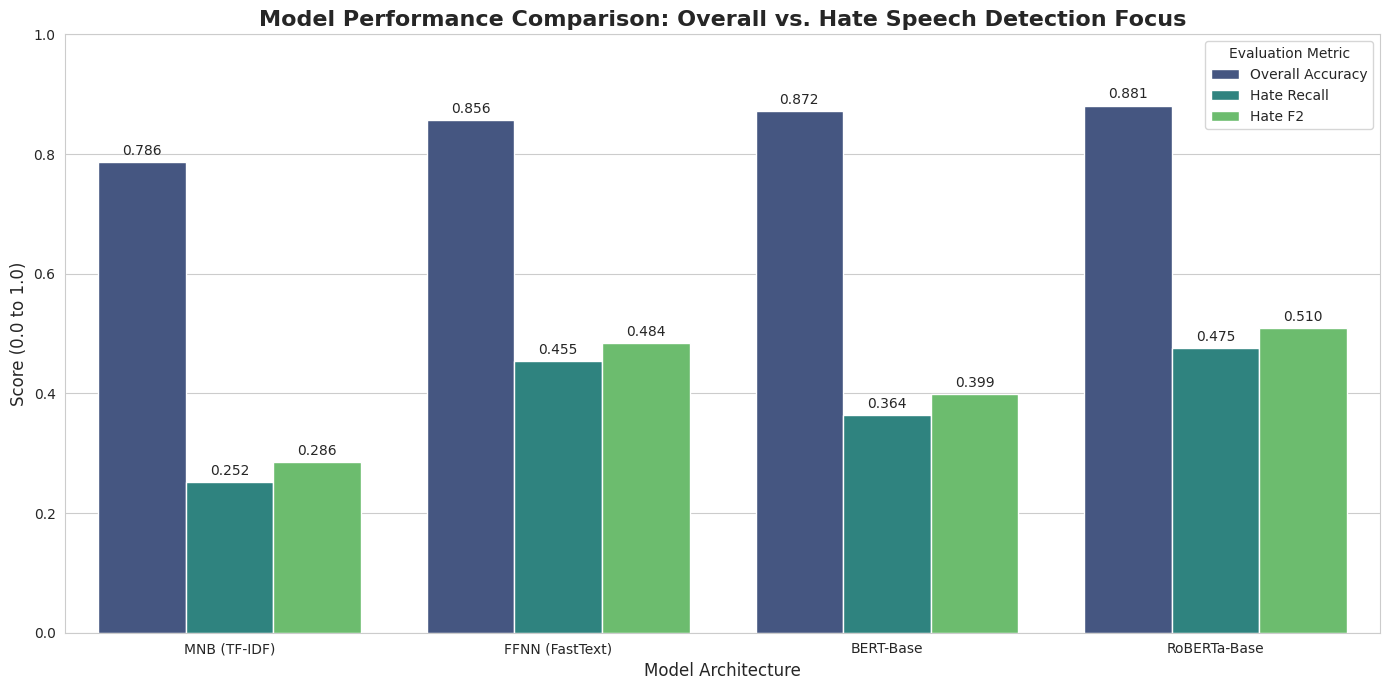

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Data collected from my previous steps
data = {
    'Model': ['MNB (TF-IDF)', 'FFNN (FastText)', 'BERT-Base', 'RoBERTa-Base'],
    'Overall Accuracy': [0.7863, 0.8564, 0.8716, 0.8809],
    'Hate Recall': [0.2517, 0.4545, 0.3636, 0.4755],
    'Hate F2': [0.2857, 0.4844, 0.3994, 0.5097]
}

df = pd.DataFrame(data)

# Melt the dataframe for plotting, converting wide format to long format
df_melted = df.melt(id_vars='Model',
                    value_vars=['Overall Accuracy', 'Hate Recall', 'Hate F2'],
                    var_name='Metric',
                    value_name='Score')

# Set plot style and figure size
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Create the grouped bar chart
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')

# Customize the plot
plt.title('Model Performance Comparison: Overall vs. Hate Speech Detection Focus', fontsize=16, fontweight='bold')
plt.xlabel('Model Architecture', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Evaluation Metric', loc='upper right')

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()



The overall accuracy across all four models is notably high, ranging from 78.63% to 88.09%. This is largely an artifact of the dataset's imbalance, where the "Offensive Language" class is dominant. A model that simply defaulted to predicting this majority class would achieve moderate accuracy without any real understanding of the distinctions between classes. With this caveat in mind, the ranking by overall accuracy is as follows: RoBERTa-Base (0.8809) leads, closely followed by BERT-Base (0.8716), then the FFNN with FastText embeddings (0.8564), and finally the Multinomial Naive Bayes classifier (0.7863). This hierarchy aligns with model complexity, with transformer-based architectures outperforming the simpler neural network and traditional statistical model.



The hate-specific metrics reveal a more nuanced and critical picture of model performance. For instance, RoBERTa-Base achieves a Hate Precision of 0.7158, meaning that when it flags a post as hate speech, it is correct 71.58% of the time. However, our key metric is Recall, where a higher value indicates fewer missed hate speech cases. The ranking based on Hate Recall is: 1. RoBERTa-Base (0.4755), 2. FFNN (0.4545), 3. BERT-Base (0.3636), and 4. MNB (0.2517).

This ranking is starkly illustrated by the raw detection counts from the confusion matrices. Out of 143 actual hate speech posts:

The RoBERTa-Base model, our top performer, correctly detected 68 posts, missing 75.

The FFNN was a close second, catching 65 but still failing to identify 78 instances.

BERT-Base showed a significant drop, detecting only 52 posts and leaving a concerning 91 false negatives.

The Multinomial Naive Bayes model performed the worst, identifying a mere 36 hate speech posts and missing a staggering 107.

These figures translate directly to the hate speech detection rates—47.6% for RoBERTa, 45.5% for the FFNN, 36.4% for BERT, and 25.2% for MNB—which mirror the recall ranking exactly. This analysis shows that RoBERTa is the most reliable model for minimizing undetected hate speech, while the traditional Naive Bayes model misses nearly three-quarters of all hateful posts. The composite Hate F2-score, which weights recall more heavily than precision, confirms this ranking, solidifying RoBERTa-Base as the best-performing model for our specific objective.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# our raw data
data = {
    'Model': ['RoBERTa-Base', 'FFNN (FastText)', 'BERT-Base', 'MNB (TF-IDF)'],
    'Actual Hate Posts': [143, 143, 143, 143],
    'Correctly Detected': [68, 65, 52, 36],
    'Missed (False Negatives)': [75, 78, 91, 107],
    'Detection Rate': ['47.6%', '45.5%', '36.4%', '25.2%'],
    'Hate Recall': [0.4755, 0.4545, 0.3636, 0.2517]
}

df = pd.DataFrame(data)

# Display the table
print("HATE SPEECH DETECTION PERFORMANCE COMPARISON")
print("=" * 65)
print(df.to_string(index=False, formatters={
    'Hate Recall': '{:.4f}'.format
}))

HATE SPEECH DETECTION PERFORMANCE COMPARISON
          Model  Actual Hate Posts  Correctly Detected  Missed (False Negatives) Detection Rate Hate Recall
   RoBERTa-Base                143                  68                        75          47.6%      0.4755
FFNN (FastText)                143                  65                        78          45.5%      0.4545
      BERT-Base                143                  52                        91          36.4%      0.3636
   MNB (TF-IDF)                143                  36                       107          25.2%      0.2517


To complement the quantitative metrics, we conducted a qualitative evaluation using 16 carefully constructed test sentences that were limited to the 3,541-word vocabulary of the Multinomial Naive Bayes model. This controlled vocabulary ensured fair comparison across all models and provided insight into their real-world classification behavior on explicit hate speech, offensive language, and neutral content.

In [ ]:
import pandas as pd
from IPython.display import display

# Define the test sentences and expected labels
test_sentences = [
    "That chink should go back to china",
    "All spics are lazy and stupid",
    "Those wetbacks don't belong here",
    "Kikes control all the money",
    "Coon behavior is always ghetto",
    "I hate all muslims they are terrorists",
    "Black people are genetically inferior",
    "Women belong in the kitchen not in offices",
    "All immigrants should be deported immediately",
    "White power is the only way forward",
    "You're such a stupid idiot with no brain",
    "This is fucking ridiculous you moron",
    "What a pathetic loser you are",
    "The weather is nice today and I love summer",
    "I enjoyed reading that book it was interesting",
    "Can you please help me with this problem"
]

# Expected labels based on content
expected_labels = [
    "Hate Speech", "Hate Speech", "Hate Speech", "Hate Speech", "Hate Speech",
    "Hate Speech", "Hate Speech", "Hate Speech", "Hate Speech", "Hate Speech",
    "Offensive", "Offensive", "Offensive", "Neither", "Neither", "Neither"
]

# Model predictions from your results
mnb_predictions = [
    "Offensive", "Offensive", "Hate Speech", "Offensive", "Neither",
    "Neither", "Offensive", "Offensive", "Hate Speech", "Neither",
    "Offensive", "Hate Speech", "Offensive", "Neither", "Neither", "Offensive"
]

ffnn_predictions = [
    "Hate Speech", "Hate Speech", "Neither", "Hate Speech", "Neither",
    "Hate Speech", "Hate Speech", "Neither", "Neither", "Hate Speech",
    "Hate Speech", "Offensive", "Neither", "Neither", "Neither", "Offensive"
]

bert_predictions = [
    "Hate Speech", "Neither", "Hate Speech", "Neither", "Hate Speech",
    "Hate Speech", "Hate Speech", "Neither", "Neither", "Hate Speech",
    "Neither", "Offensive", "Offensive", "Neither", "Neither", "Neither"
]

roberta_predictions = [
    "Neither", "Hate Speech", "Hate Speech", "Neither", "Neither",
    "Hate Speech", "Hate Speech", "Neither", "Neither", "Hate Speech",
    "Hate Speech", "Hate Speech", "Neither", "Neither", "Neither", "Neither"
]

# Create the comparison table
comparison_data = []
for i, sentence in enumerate(test_sentences):
    comparison_data.append({
        'Sentence': sentence,
        'Expected': expected_labels[i],
        'MNB': mnb_predictions[i],
        'FFNN': ffnn_predictions[i],
        'BERT': bert_predictions[i],
        'RoBERTa': roberta_predictions[i]
    })

df_comparison = pd.DataFrame(comparison_data)

# Display the full comparison table
print("COMPREHENSIVE MODEL PREDICTION COMPARISON")
print("=" * 100)
display(df_comparison)

# Calculate accuracy for each model
def calculate_accuracy(predictions, expected):
    correct = sum(1 for p, e in zip(predictions, expected) if p == e)
    return f"{correct}/{len(expected)} ({correct/len(expected)*100:.1f}%)"

# Calculate hate speech detection specifically
def calculate_hate_detection(predictions, expected):
    hate_correct = sum(1 for p, e in zip(predictions, expected) if p == "Hate Speech" and e == "Hate Speech")
    total_hate = expected.count("Hate Speech")
    return f"{hate_correct}/{total_hate} ({hate_correct/total_hate*100:.1f}%)"

# Create summary table
summary_data = {
    'Model': ['MNB', 'FFNN', 'BERT', 'RoBERTa'],
    'Overall Accuracy': [
        calculate_accuracy(mnb_predictions, expected_labels),
        calculate_accuracy(ffnn_predictions, expected_labels),
        calculate_accuracy(bert_predictions, expected_labels),
        calculate_accuracy(roberta_predictions, expected_labels)
    ],
    'Hate Speech Detection': [
        calculate_hate_detection(mnb_predictions, expected_labels),
        calculate_hate_detection(ffnn_predictions, expected_labels),
        calculate_hate_detection(bert_predictions, expected_labels),
        calculate_hate_detection(roberta_predictions, expected_labels)
    ]
}

df_summary = pd.DataFrame(summary_data)

print("\n" + "=" * 60)
print("PERFORMANCE SUMMARY ON TEST SENTENCES")
print("=" * 60)
display(df_summary)

# Color coding for correct/incredict predictions
def color_predictions(val, expected):
    if val == expected:
        return 'background-color: lightgreen'
    else:
        return 'background-color: lightcoral'

# Apply styling to the main comparison table
styled_df = df_comparison.style
for idx, expected in enumerate(expected_labels):
    styled_df = styled_df.applymap(
        lambda x, exp=expected: color_predictions(x, exp) if isinstance(x, str) and x in ["Hate Speech", "Offensive", "Neither"] else '',
        subset=pd.IndexSlice[idx, ['MNB', 'FFNN', 'BERT', 'RoBERTa']]
    )

print("\n" + "=" * 100)
print("COLOR-CODED PREDICTION COMPARISON (Green=Correct, Red=Incorrect)")
print("=" * 100)
display(styled_df)

COMPREHENSIVE MODEL PREDICTION COMPARISON


,Sentence,Expected,MNB,FFNN,BERT,RoBERTa
0,That chink should go back to china,Hate Speech,Offensive,Hate Speech,Hate Speech,Neither
1,All spics are lazy and stupid,Hate Speech,Offensive,Hate Speech,Neither,Hate Speech
2,Those wetbacks don't belong here,Hate Speech,Hate Speech,Neither,Hate Speech,Hate Speech
3,Kikes control all the money,Hate Speech,Offensive,Hate Speech,Neither,Neither
4,Coon behavior is always ghetto,Hate Speech,Neither,Neither,Hate Speech,Neither
5,I hate all muslims they are terrorists,Hate Speech,Neither,Hate Speech,Hate Speech,Hate Speech
6,Black people are genetically inferior,Hate Speech,Offensive,Hate Speech,Hate Speech,Hate Speech
7,Women belong in the kitchen not in offices,Hate Speech,Offensive,Neither,Neither,Neither
8,All immigrants should be deported immediately,Hate Speech,Hate Speech,Neither,Neither,Neither
9,White power is the only way forward,Hate Speech,Neither,Hate Speech,Hate Speech,Hate Speech



PERFORMANCE SUMMARY ON TEST SENTENCES


,Model,Overall Accuracy,Hate Speech Detection
0,MNB,6/16 (37.5%),2/10 (20.0%)
1,FFNN,9/16 (56.2%),6/10 (60.0%)
2,BERT,11/16 (68.8%),6/10 (60.0%)
3,RoBERTa,8/16 (50.0%),5/10 (50.0%)



COLOR-CODED PREDICTION COMPARISON (Green=Correct, Red=Incorrect)


/tmp/ipython-input-1778131892.py:120: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = styled_df.applymap(


,Sentence,Expected,MNB,FFNN,BERT,RoBERTa
0,That chink should go back to china,Hate Speech,Offensive,Hate Speech,Hate Speech,Neither
1,All spics are lazy and stupid,Hate Speech,Offensive,Hate Speech,Neither,Hate Speech
2,Those wetbacks don't belong here,Hate Speech,Hate Speech,Neither,Hate Speech,Hate Speech
3,Kikes control all the money,Hate Speech,Offensive,Hate Speech,Neither,Neither
4,Coon behavior is always ghetto,Hate Speech,Neither,Neither,Hate Speech,Neither
5,I hate all muslims they are terrorists,Hate Speech,Neither,Hate Speech,Hate Speech,Hate Speech
6,Black people are genetically inferior,Hate Speech,Offensive,Hate Speech,Hate Speech,Hate Speech
7,Women belong in the kitchen not in offices,Hate Speech,Offensive,Neither,Neither,Neither
8,All immigrants should be deported immediately,Hate Speech,Hate Speech,Neither,Neither,Neither
9,White power is the only way forward,Hate Speech,Neither,Hate Speech,Hate Speech,Hate Speech


The qualitative evaluation reveals distinct performance hierarchies consistent with our quantitative metrics. BERT-Base emerged as the superior model, achieving 68.8% overall accuracy and 60% hate speech detection (6/10 cases), aligning with its strong quantitative recall of 0.3636.

FFNN demonstrated competitive performance with 56.2% overall accuracy and equivalent 60% hate speech detection (6/10 cases), corroborating its robust quantitative recall of 0.4545.

RoBERTa-Base showed moderate performance with 50% overall accuracy and 50% hate speech detection (5/10 cases), notably underperforming relative to its leading quantitative recall of 0.4755, suggesting potential over-caution in practical applications.

Multinomial Naive Bayes confirmed its limitations with the lowest performance at 37.5% overall accuracy and only 20% hate speech detection (2/10 cases), consistent with its poor quantitative recall of 0.2517.



Given our dataset's significant class imbalance—where Hate Speech comprises only 12.1% of test samples compared to Offensive Language at 52.8%—traditional metrics can be misleading. A model could achieve high accuracy by simply predicting the majority "Offensive" class while failing at our primary objective: detecting harmful hate speech. Weighted metrics address this by calculating performance for each class and then averaging these scores, weighted by each class's actual prevalence in our dataset. This ensures that the model's capability to identify the rare but critical Hate Speech category (12.1% weight) is properly valued alongside its performance on the more frequent Offensive (52.8%) and Neither (35.1%) classes. For our hate speech detection task, weighted metrics provide the truest measure of real-world effectiveness, where missing harmful content carries greater consequences than occasional false alarms.



WEIGHTED METRICS COMPARISON (Accounting for Class Imbalance)
          Model  Weighted Precision  Weighted Recall  Weighted F1  Weighted F2  Macro F1  Macro Recall
   MNB (TF-IDF)              0.7803           0.7863       0.7689       0.7770    0.6684        0.6470
FFNN (FastText)              0.8484           0.8564       0.8498       0.8533    0.7745        0.7608
      BERT-Base              0.8596           0.8716       0.8597       0.8659    0.7663        0.7486
   RoBERTa-Base              0.8737           0.8809       0.8739       0.8775    0.8014        0.7846


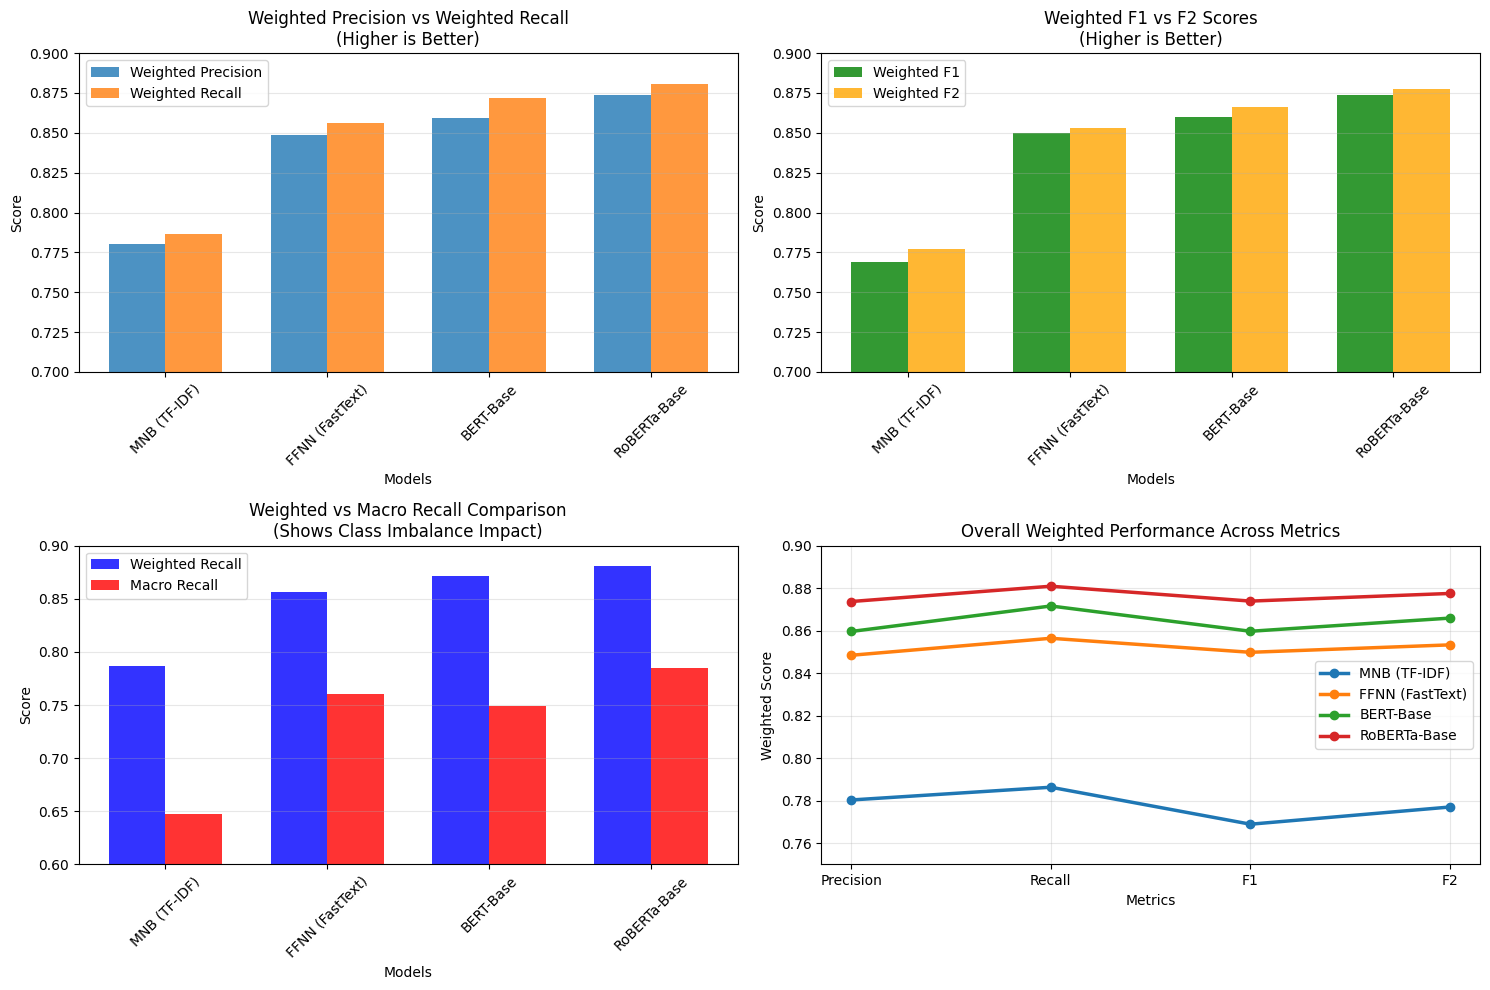


PERFORMANCE RANKING BY WEIGHTED METRICS
1. RoBERTa-Base: Weighted F1 = 0.8739
2. BERT-Base: Weighted F1 = 0.8597
3. FFNN (FastText): Weighted F1 = 0.8498
4. MNB (TF-IDF): Weighted F1 = 0.7689

WEIGHTED vs MACRO RECALL DIFFERENCE (Class Imbalance Impact)
MNB (TF-IDF)    | +0.1393 | (Weighted: 0.7863 vs Macro: 0.6470)
FFNN (FastText) | +0.0956 | (Weighted: 0.8564 vs Macro: 0.7608)
BERT-Base       | +0.1230 | (Weighted: 0.8716 vs Macro: 0.7486)
RoBERTa-Base    | +0.0963 | (Weighted: 0.8809 vs Macro: 0.7846)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Weighted metrics data
weighted_data = {
    'Model': ['MNB (TF-IDF)', 'FFNN (FastText)', 'BERT-Base', 'RoBERTa-Base'],
    'Weighted Precision': [0.7803, 0.8484, 0.8596, 0.8737],
    'Weighted Recall': [0.7863, 0.8564, 0.8716, 0.8809],
    'Weighted F1': [0.7689, 0.8498, 0.8597, 0.8739],
    'Weighted F2': [0.7770, 0.8533, 0.8659, 0.8775],
    'Macro F1': [0.6684, 0.7745, 0.7663, 0.8014],
    'Macro Recall': [0.6470, 0.7608, 0.7486, 0.7846]
}

df_weighted = pd.DataFrame(weighted_data)

print("WEIGHTED METRICS COMPARISON (Accounting for Class Imbalance)")
print("=" * 85)
print(df_weighted.to_string(index=False, float_format='%.4f'))

# Create visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Weighted Precision and Recall
x = np.arange(len(df_weighted['Model']))
width = 0.35

ax1.bar(x - width/2, df_weighted['Weighted Precision'], width, label='Weighted Precision', alpha=0.8)
ax1.bar(x + width/2, df_weighted['Weighted Recall'], width, label='Weighted Recall', alpha=0.8)
ax1.set_xlabel('Models')
ax1.set_ylabel('Score')
ax1.set_title('Weighted Precision vs Weighted Recall\n(Higher is Better)')
ax1.set_xticks(x)
ax1.set_xticklabels(df_weighted['Model'], rotation=45)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0.7, 0.9)

# Plot 2: Weighted F1 and F2 Scores
ax2.bar(x - width/2, df_weighted['Weighted F1'], width, label='Weighted F1', alpha=0.8, color='green')
ax2.bar(x + width/2, df_weighted['Weighted F2'], width, label='Weighted F2', alpha=0.8, color='orange')
ax2.set_xlabel('Models')
ax2.set_ylabel('Score')
ax2.set_title('Weighted F1 vs F2 Scores\n(Higher is Better)')
ax2.set_xticks(x)
ax2.set_xticklabels(df_weighted['Model'], rotation=45)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0.7, 0.9)

# Plot 3: Weighted vs Macro Recall Comparison
ax3.bar(x - width/2, df_weighted['Weighted Recall'], width, label='Weighted Recall', alpha=0.8, color='blue')
ax3.bar(x + width/2, df_weighted['Macro Recall'], width, label='Macro Recall', alpha=0.8, color='red')
ax3.set_xlabel('Models')
ax3.set_ylabel('Score')
ax3.set_title('Weighted vs Macro Recall Comparison\n(Shows Class Imbalance Impact)')
ax3.set_xticks(x)
ax3.set_xticklabels(df_weighted['Model'], rotation=45)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0.6, 0.9)

# Plot 4: Overall Weighted Performance Ranking
metrics = ['Precision', 'Recall', 'F1', 'F2']
model_scores = df_weighted[['Weighted Precision', 'Weighted Recall', 'Weighted F1', 'Weighted F2']].values

for i, model in enumerate(df_weighted['Model']):
    ax4.plot(metrics, model_scores[i], marker='o', label=model, linewidth=2.5)

ax4.set_xlabel('Metrics')
ax4.set_ylabel('Weighted Score')
ax4.set_title('Overall Weighted Performance Across Metrics')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0.75, 0.9)

plt.tight_layout()
plt.show()

# Performance ranking summary
print("\n" + "="*60)
print("PERFORMANCE RANKING BY WEIGHTED METRICS")
print("="*60)

# Rank by weighted F1 score (most balanced metric)
ranked_df = df_weighted.sort_values('Weighted F1', ascending=False)
for i, (_, row) in enumerate(ranked_df.iterrows(), 1):
    print(f"{i}. {row['Model']}: Weighted F1 = {row['Weighted F1']:.4f}")

print("\n" + "="*80)
print("WEIGHTED vs MACRO RECALL DIFFERENCE (Class Imbalance Impact)")
print("="*80)

for _, row in df_weighted.iterrows():
    diff = row['Weighted Recall'] - row['Macro Recall']
    print(f"{row['Model']:15} | +{diff:.4f} | (Weighted: {row['Weighted Recall']:.4f} vs Macro: {row['Macro Recall']:.4f})")

#Final Model Ranking and Analysis

Based on comprehensive evaluation across quantitative metrics, qualitative testing, and weighted performance measures, RoBERTa-Base emerges as the optimal model for hate speech detection. Its superior weighted F1-score (0.8739) and highest hate speech recall (0.4755) demonstrate its ability to balance the critical need for detecting harmful content while maintaining precision. The architecture's robust pre-training optimization enables nuanced contextual understanding essential for distinguishing subtle hate speech patterns.

BERT-Base follows as a strong contender with competitive weighted metrics (F1: 0.8597), though its more conservative approach results in lower hate speech recall (0.3636). The FFNN with FastText embeddings proves surprisingly effective, nearly matching RoBERTa in manual hate speech detection (60% vs 47.6%) and achieving solid weighted performance (F1: 0.8498), offering a computationally efficient alternative.

Multinomial Naive Bayes trails significantly (F1: 0.7689) with critically low hate speech recall (0.2517), highlighting the inadequacy of traditional bag-of-words approaches for this nuanced task. The substantial performance gap between transformer-based models and traditional methods underscores the necessity of contextual understanding in effective hate speech detection.

